# Project EDA: Expert Discovery System and Collaboration Network Analysis with HORUS data

**General Objective**: To develop an intelligent model that identifies latent areas of expertise and recommends thesis advisors based on semantic affinity, overcoming traditional administrative classifications.

**Main Mining Technique**: Topic detection (Topic Modeling) with the use of embeddings (Language Models - LLMs) for vector representation of descriptions (e.g., SBERT or ada-002) combined with Hierarchical Clustering (e.g., HDBSCAN).

**Granularity level**: The base level of granularity is academic productions. For now, data has been collected from a single university campus (sede Bogotá) and its faculties (without a more specific breakdown by departments, mainly for ease of extraction, as we have not yet been given access to the official databases). However, I this would still be acceptable to a certain extent, as the focus is on professors and their output rather than on any divisions that may exist, allowing the data to reveal the actual structure of research  (thematic affinity rather than by faculty or department). Also, we will only consider productions of active professors.

# 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import nltk

from wordcloud import WordCloud
from pathlib import Path
from itertools import combinations
from collections import Counter
from IPython.display import display
from nltk.corpus import stopwords as nltk_stopwords
from collections import Counter

### 1.1. Environment Configuration (Mounting Drive)

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data/")
else:
    base_path = Path("../data/")

### 1.2. Faculty-Level Data Loading

Load faculty-specific datasets and assign the faculty label explicitly.

In [3]:
products_engineering = pd.read_excel(base_path / "raw/productos_ingenieria.xlsx").assign(faculty='Ingeniería')
products_arts = pd.read_excel(base_path / "raw/productos_artes.xlsx").assign(faculty='Artes')
products_agricultural_sciences = pd.read_excel(base_path / "raw/productos_ciencias_agrarias.xlsx").assign(faculty='Ciencias Agrarias')
products_economic_sciences = pd.read_excel(base_path / "raw/productos_ciencias_economicas.xlsx").assign(faculty='Ciencias Económicas')
products_human_sciences = pd.read_excel(base_path / "raw/productos_ciencias_humanas.xlsx").assign(faculty='Ciencias Humanas')
products_sciences = pd.read_excel(base_path / "raw/productos_ciencias.xlsx").assign(faculty='Ciencias')
products_law = pd.read_excel(base_path / "raw/productos_derecho.xlsx").assign(faculty='Derecho')
products_nursing = pd.read_excel(base_path / "raw/productos_enfermeria.xlsx").assign(faculty='Enfermería')
products_medicine = pd.read_excel(base_path / "raw/productos_medicina.xlsx").assign(faculty='Medicina')
products_dentistry = pd.read_excel(base_path / "raw/productos_odontologia.xlsx").assign(faculty='Odontología')
products_veterinary = pd.read_excel(base_path / "raw/productos_veterinaria.xlsx").assign(faculty='Veterinaria')

products_bogota = pd.concat([
    products_engineering,
    products_arts,
    products_agricultural_sciences,
    products_economic_sciences,
    products_human_sciences,
    products_sciences,
    products_law,
    products_nursing,
    products_medicine,
    products_dentistry,
    products_veterinary
], ignore_index=True)

column_mapping = {
    'Título original': 'original_title',
    'Descripción original': 'original_description',
    'Revista / Conferencia': 'journal_conference',
    'Coautores': 'coauthors',
    'Doi': 'doi',
    'ISBN': 'isbn',
    'ISSN': 'issn',
    'Citaciones': 'citations',
    'Idioma': 'language',
    'Fecha': 'date',
    'Tipo': 'type',
    'Fuente': 'source',
    'Enlace': 'link',
    'faculty': 'faculty'
}
products_bogota.rename(columns=column_mapping, inplace=True)

research_professors = pd.read_csv(base_path / 'external/docentes_investigadores.csv')
column_mapping_2 = {
    'Nombre': 'name',
    'Vinculación': 'affiliation',
    'Cantidad de productos': 'product_count'
}
research_professors.rename(columns=column_mapping_2, inplace=True)
active_research_professors = research_professors[research_professors['affiliation'] == 'Activo'].reset_index(drop=True)

### 1.3. Useful functions

In [4]:
# Process coauthors
def count_coauthors(text):
    if pd.isna(text) or str(text).strip() == '':
        return 0
    return len([x for x in str(text).split(',') if x.strip()])

# Extract all individual coauthors
def extract_coauthors(text):
    if pd.isna(text):
        return []
    return [name.strip() for name in str(text).split(',') if name.strip()]

# Normalize names for comparison
def normalize_name(name):
    if pd.isna(name):
        return ""
    # Convert to lowercase and remove accents
    name = str(name).lower()
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                   if unicodedata.category(c) != 'Mn')
    # Remove periods and commas
    name = re.sub(r'[.,]', '', name)
    # Normalize whitespace
    name = ' '.join(name.split())
    return name

# Group names by similarity (surname)
def extract_surname(name_norm):
    parts = name_norm.split()
    if len(parts) > 0:
        return parts[-1]  # Last element (likely the surname)
    return name_norm

# Convention strings to treat as missing
NULL_CONVENTIONS = ['no reportado', 'no disponible', 'sin información', 'n/a', 'na', 'none', '-', 'nd']
def is_null_by_convention(val):
    if pd.isna(val):
        return True
    return str(val).strip().lower() in NULL_CONVENTIONS

# Simple heuristic: infer language from title characters if missing
def infer_language_heuristic(title):
    """Very rough heuristic — flag for manual review or langdetect library."""
    if pd.isna(title) or str(title).strip() == '':
        return 'Desconocido'
    title = str(title).lower()
    # Spanish stopwords signals
    if any(w in title for w in [' de ', ' del ', ' la ', ' el ', ' en ', ' y ', ' con ', ' para ']):
        return 'Español (inferido)'
    elif any(w in title for w in [' the ', ' of ', ' and ', ' for ', ' in ', ' with ']):
        return 'Inglés (inferido)'
    return 'Indeterminado'

# Normalize names for matching (surnames differ from full names)
def normalize_for_match(name):
    name = str(name).lower().strip()
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                   if unicodedata.category(c) != 'Mn')
    name = re.sub(r'[.,]', '', name)
    return ' '.join(name.split())

# Check which coauthors are active professors
def is_active_professor(name, professors_set):
    return normalize_for_match(name) in professors_set

# Filter: keep only productions where at least one coauthor is an active professor
def has_active_professor(coauthors_str, professors_set):
    names = extract_coauthors(coauthors_str)
    return any(normalize_for_match(n) in professors_set for n in names)

noisy_expressions = [
    r'\btexto tomado\b',
    r'\buniversidad nacional\b',
    r'\bnacional colombia\b',
    r'\bet al\b'
]

stopwords_auto_df = set()

def normalize_text(text, remove_accents=True, lowercase=True):
    """
    Normalize text: lowercase and remove accents.
    
    Args:
        text: Text to normalize
        remove_accents: If True, remove accents
        lowercase: If True, convert to lowercase
    
    Returns:
        Normalized text
    """
    if pd.isna(text) or str(text).strip() == '':
        return ""
    
    text = str(text)
    
    if lowercase:
        text = text.lower()
    
    if remove_accents:
        text = ''.join(
            c for c in unicodedata.normalize('NFD', text)
            if unicodedata.category(c) != 'Mn'
        )
    
    return text

def clean_text(text, min_token_length=2, remove_numbers=True):
    """
    Clean text by removing punctuation, short tokens and numbers.
    
    Args:
        text: Text to clean
        min_token_length: Minimum token length to keep
        remove_numbers: If True, remove tokens that are only numbers
    
    Returns:
        Cleaned text
    """
    if pd.isna(text) or str(text).strip() == '':
        return ""
    
    text = str(text)
    
    # Remove punctuation (keep spaces)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Normalize whitespace
    text = ' '.join(text.split())
    
    # Split into tokens
    tokens = text.split()
    
    # Filter tokens
    filtered_tokens = []
    for token in tokens:
        # Remove very short tokens
        if len(token) < min_token_length:
            continue
        
        # Remove tokens that are only numbers
        if remove_numbers and token.isdigit():
            continue
        
        filtered_tokens.append(token)
    
    return ' '.join(filtered_tokens)

def clean_thematic_noise(text):

    if not text or str(text).strip() == "":
        return ""

    t = str(text)

    for pattern in noisy_expressions:
        t = re.sub(pattern, " ", t, flags=re.IGNORECASE)

    tokens = t.split()

    tokens = [
        tok for tok in tokens
        if tok not in stopwords_auto_df
    ]

    return " ".join(tokens)



### 1.4. Stopwords Definition and Processing Functions

In [5]:
# -----------------------------
# SPANISH STOPWORDS
# -----------------------------
STOPWORDS_ES = {
    'el','la','los','las','lo',
    'un','una','unos','unas','uno',
    'de','del','al',
    'que','y','o','u','ni',
    'a','ante','bajo','con','contra','desde','durante','en','entre',
    'hacia','hasta','para','por','segun','sin','sobre','tras',

    'ser','estar','haber','tener','hacer','poder','decir','ir','ver','dar',
    'saber','querer','llegar','pasar','deber','poner','parecer',
    'quedar','creer','hablar','llevar','dejar','seguir','encontrar',

    'este','esta','estos','estas',
    'ese','esa','esos','esas',
    'aquel','aquella','aquellos','aquellas',
    'esto','eso','aquello',

    'yo','tu','tú','el','ella','nosotros','nosotras','ellos','ellas',
    'me','te','se','nos','les','le','lo','la','los','las',

    'mi','mis','tu','tus','su','sus','nuestro','nuestra','nuestros','nuestras',

    'si','no','sí',
    'muy','mas','más','menos','tan','tanto','tanta','tantos','tantas',

    'tambien','también','ya','aun','aún',
    'asi','así',

    'cuando','donde','dónde','como','cómo','porque','porqué','pues',

    'uno','dos','tres',

    'algo','alguien','alguno','algunos','alguna','algunas',
    'nada','nadie','todo','todos','todas',

    'mismo','misma','mismos','mismas',

    'tiempo','dia','día','ano','año'
}


# -----------------------------
# ENGLISH STOPWORDS
# -----------------------------
STOPWORDS_EN = {
    'the','a','an','and','or','but',
    'of','to','in','on','for','with','at','by','from',
    'into','onto','about','over','under','between','through',

    'is','are','was','were','be','been','being',
    'have','has','had','having',
    'do','does','did',

    'this','that','these','those',
    'there','here',

    'i','you','he','she','it','we','they',
    'me','him','her','us','them',

    'my','your','his','her','its','our','their',

    'what','which','who','whom','whose',
    'when','where','why','how',

    'can','could','should','would','may','might','must',

    'not','no','nor','only','just','also','even',

    'very','more','most','less',

    'one','two','three',

    'new','old','same','other','another'
}


# -----------------------------
# ACADEMIC / SCIENTIFIC NOISE
# -----------------------------
STOPWORDS_CONTEXT = {

    # institutions / geography
    'colombia','colombian',
    'universidad','university',
    'nacional','national',
    'bogota','bogotá',

    # research words
    'study','studies','research','paper','article',
    'work','works','project',

    # results words
    'result','results','finding','findings','found',

    # methodological words
    'method','methods','methodology',
    'approach','approaches',
    'analysis','analyses',
    'model','models',
    'data','dataset',
    'variable','variables',
    'process','processes',
    'system','systems',

    # reporting language
    'based','using','use','used',
    'show','shows','shown',
    'present','presents','presented',
    'propose','proposed',
    'evaluate','evaluated',

    # generic academic words
    'case','cases',
    'group','groups',
    'type','types',
    'level','levels',
    'value','values',
    'factor','factors',

    'high','low','large','small',

    'different','various','several',

    'general','overall',

    'during','within','across',

    # spanish academic filler
    'resultado','resultados',
    'analisis','análisis',
    'estudio','estudios', 'traves',
    'investigacion','investigación',
    'metodo','método', 'such', 'mayor', 'presente',
    'metodos','métodos', 'años', 'diseño',
    'modelo','modelos', 'anos', 'diseno',
    'datos', 'uso', 'partir', 'objetivo', 
    'proceso','procesos',
    'sistema','sistemas',

    'forma','nivel','valor',

    'caso','casos',
    'grupo','grupos',

    'diferente','diferentes',

    'generalmente',

    'durante',

    'ademas','además',

    'cual','cuales',

    'son','sus','esta','este','esto',
    'han','ha','fue','tiene'
}

STOPWORDS_ALL = STOPWORDS_ES | STOPWORDS_EN | STOPWORDS_CONTEXT

noisy_expressions = [
    r'\btexto tomado\b',
    r'\buniversidad nacional\b',
    r'\bnacional colombia\b',
    r'\bet al\b'
]

try:
    _ = nltk_stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)

STOPWORDS_NLTK_EN = set(nltk_stopwords.words('english'))
STOPWORDS_NLTK_ES = set(nltk_stopwords.words('spanish'))
print(f"NLTK stopwords loaded: EN={len(STOPWORDS_NLTK_EN)}, ES={len(STOPWORDS_NLTK_ES)}")


def _normalize_stopword_set(words):
    normalized = set()
    for w in words:
        if pd.isna(w):
            continue
        w = str(w).strip().lower()
        if not w:
            continue
        w = ''.join(
            c for c in unicodedata.normalize('NFD', w)
            if unicodedata.category(c) != 'Mn'
        )
        normalized.add(w)
    return normalized

# Normalize stopword sets
STOPWORDS_ES = _normalize_stopword_set(STOPWORDS_ES)
STOPWORDS_EN = _normalize_stopword_set(STOPWORDS_EN)
STOPWORDS_NLTK_ES = _normalize_stopword_set(STOPWORDS_NLTK_ES)
STOPWORDS_NLTK_EN = _normalize_stopword_set(STOPWORDS_NLTK_EN)
STOPWORDS_CONTEXT = _normalize_stopword_set(STOPWORDS_CONTEXT)

# Reinforce contextual noise detected in EDA
STOPWORDS_CONTEXT_EXTRA = {
    'proyecto', 'trabajo', 'uso', 'mayor', 'parte', 'cada', 'puede'
}
STOPWORDS_CONTEXT |= _normalize_stopword_set(STOPWORDS_CONTEXT_EXTRA)

# Unified list: remove stopwords from both languages + context
STOPWORDS_COMBINED = STOPWORDS_ES | STOPWORDS_EN | STOPWORDS_NLTK_ES | STOPWORDS_NLTK_EN
STOPWORDS_ALL = STOPWORDS_COMBINED | STOPWORDS_CONTEXT

def remove_stopwords(text, stopwords=None):
    if pd.isna(text) or str(text).strip() == '':
        return ""

    if stopwords is None:
        stopwords = STOPWORDS_ALL

    tokens = str(text).split()
    filtered_tokens = [tok for tok in tokens if tok.lower() not in stopwords]

    return ' '.join(filtered_tokens)

def preprocess_text_full(text, 
                         lowercase=True,
                         remove_accents=True, 
                         min_token_length=2,
                         remove_numbers=True,
                         remove_stopwords_flag=True):
    """
    Full text preprocessing pipeline.

    Steps:
    1. Normalization (lowercase, accents)
    2. Cleaning (punctuation, short tokens, numbers)
    3. Stopword removal using STOPWORDS_ALL (ES + EN + context)
    4. Thematic noise cleaning
    """
    if pd.isna(text) or str(text).strip() == '':
        return ""

    text = normalize_text(text, remove_accents=remove_accents, lowercase=lowercase)
    text = clean_text(text, min_token_length=min_token_length, remove_numbers=remove_numbers)

    if remove_stopwords_flag:
        text = remove_stopwords(text)

    text = clean_thematic_noise(text)
    return text.strip()

print(
    f"Total stopwords: base={len(STOPWORDS_COMBINED)}, ",
    f"context={len(STOPWORDS_CONTEXT)}, total={len(STOPWORDS_ALL)}"
)

NLTK stopwords loaded: EN=198, ES=313
Total stopwords: base=570,  context=127, total=684


### 1.5. Filter to active professors only

In [6]:
# Build a set of normalized names from the CSV
active_professors_names = set(
    active_research_professors['name']
    .dropna()
    .apply(normalize_for_match)
)

active_mask = products_bogota['coauthors'].apply(
    lambda x: has_active_professor(x, active_professors_names)
)

products_bogota = products_bogota[active_mask].copy()
print(f"Products with at least one active professor: {len(products_bogota)}")
print(f"Products excluded: {len(active_mask) - active_mask.sum()}")

Products with at least one active professor: 109836
Products excluded: 43488


# 2. EDA

This Exploratory Data Analysis (EDA) aims to understand the structure, quality, and behavioral patterns of academic production data across faculties. It begins with data validation, examining dimensions, missing values, duplicates, and consistency in key fields such as dates and text columns. It then explores categorical distributions (faculty, type, source, language) to identify dominant patterns and concentration effects. The analysis also investigates authorship dynamics, including coauthor counts, productivity distribution (long-tail behavior), collaboration frequency, and potential name disambiguation issues.

## 2.1. Dimensional overview

In [7]:
print("Dimensions (rows, columns):", products_bogota.shape)
products_bogota.sample(5, random_state=42)

Dimensions (rows, columns): (109836, 14)


,original_title,original_description,journal_conference,coauthors,doi,isbn,issn,citations,language,date,type,source,link,faculty
39211,Metodologías de Ajuste de Riesgo en Seguros Ob...,NaN,NaN,Chicaiza Becerra Liliana Alejandra,NaN,NaN,NaN,0.0,Español,11/03/2010,Tesis Maestría,SARA,NaN,Ciencias Económicas
106566,La Paradoja Constituyente De Las Cooperativas ...,NaN,Revista de Economía Solidária,Munera Ruiz Leopoldo Alberto,NaN,NaN,16475968,0.0,Español,01/06/2011,Artículo de revista,SARA,NaN,Derecho
109447,Antonio Gramsci y la crisis de hegemonía : la ...,NaN,NaN,Herrera Zgaib Miguel Angel,NaN,NaN,NaN,0.0,Español,01/01/1989,Tesis Maestría,BibliotecasUNAL,NaN,Derecho
83238,LAUREA MAGISTRALE IN MATEMATICA (MAGISTER EN M...,No Reportado,NaN,Artigiani Mauro,NaN,NaN,NaN,0.0,Galicia,07/02/2011,Tesis Maestría,SARA,NaN,Ciencias
1413,THRESHOLDS REDUNDANCY OF EARLY WARNING SYSTEM ...,The study explores a novel methodology to dete...,Reder,"Ramos Cañón Alfonso Mariano, Munévar Maddy, Pr...",10.55467/reder.v7i2.129,NaN,07198477,0.0,Inglés,01/01/2023,Artículo de revista,SCOPUS,https://dx.doi.org/10.55467/reder.v7i2.129 - ...,Ingeniería


In [8]:
products_bogota.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109836 entries, 0 to 153323
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   original_title        109835 non-null  object 
 1   original_description  69928 non-null   object 
 2   journal_conference    67984 non-null   object 
 3   coauthors             109836 non-null  object 
 4   doi                   26779 non-null   object 
 5   isbn                  9731 non-null    object 
 6   issn                  43700 non-null   object 
 7   citations             99684 non-null   float64
 8   language              102103 non-null  object 
 9   date                  109836 non-null  object 
 10  type                  109836 non-null  object 
 11  source                109836 non-null  object 
 12  link                  45732 non-null   object 
 13  faculty               109836 non-null  object 
dtypes: float64(1), object(13)
memory usage: 12.6+ MB


In [9]:
active_research_professors.sample(5, random_state=42)

,name,affiliation,product_count
1118,Espinosa Hernández Armando,Activo,34
1653,Aya Angarita Sandra Liliana,Activo,12
1864,Marin Cadavid Luis Fernando,Activo,4
941,Parra Pineda Mario Orlando,Activo,44
331,Villegas Bolaños Nancy Liliana,Activo,110


In [10]:
active_research_professors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1929 entries, 0 to 1928
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           1929 non-null   object
 1   affiliation    1929 non-null   object
 2   product_count  1929 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 45.3+ KB


## 2.2. Missing Values & Uniqueness Analysis

In [11]:
columns_summary = pd.DataFrame({
    "dtype": products_bogota.dtypes.astype(str),
    "null": products_bogota.isna().sum(),
    "null_%": (products_bogota.isna().mean() * 100).round(2),
    "unique": products_bogota.nunique(dropna=True)
}).sort_values(["null_%", "unique"], ascending=[False, True])

columns_summary

,dtype,null,null_%,unique
isbn,object,100105,91.14,6073
doi,object,83057,75.62,25188
issn,object,66136,60.21,9587
link,object,64104,58.36,43269
journal_conference,object,41852,38.10,13456
original_description,object,39908,36.33,59491
citations,float64,10152,9.24,366
language,object,7733,7.04,30
faculty,object,0,0.00,11
source,object,0,0.00,12


## 2.3. Duplicate Detection

In [12]:
duplicates = products_bogota.duplicated().sum()
print("Duplicates:", duplicates)
print("Duplicates percentage:", round((duplicates / len(products_bogota)) * 100, 2), "%")

products_bogota.describe(include="all").transpose()

Duplicates: 29
Duplicates percentage: 0.03 %


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
original_title,109835,104658,Editorial,278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_description,69928,59491,No Reportado,5822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
journal_conference,67984,13456,Universidad Nacional de Colombia,12150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coauthors,109836,48039,Rangel Churio Jesus Orlando,284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doi,26779,25188,10.12804/REVISTAS.UROSARIO.EDU.CO,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
isbn,9731,6073,9789585949133,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issn,43700,9587,01202650,664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
citations,99684.0,NaN,NaN,NaN,4.779904,37.70105,0.0,0.0,0.0,0.0,7616.0
language,102103,30,Español,60001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,109836,8803,01/01/2013,3485,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.4. Date Validation and temporal analysis

In [13]:
date_dt = pd.to_datetime(products_bogota["date"], errors="coerce", dayfirst=True)

date_summary = pd.DataFrame({
    "valid_dates": [date_dt.notna().sum()],
    "invalid_dates": [date_dt.isna().sum()],
    "date_min": [date_dt.min()],
    "date_max": [date_dt.max()]
})

display(date_summary)

publications_per_year = date_dt.dt.year.value_counts().sort_index()
publications_per_year.to_frame("records")

,valid_dates,invalid_dates,date_min,date_max
0,109836,0,1965-01-02,2025-12-31


,records
date,
1965,2
1966,4
1967,2
1968,4
1969,3
...,...
2021,4662
2022,4778
2023,4408


### 2.4.1. Temporal Analysis

PUBLICATIONS TEMPORAL ANALYSIS
Records with valid date: 109836 (100.0%)
Time range: 1965 - 2025

--- Annual Production ---


,publications
year,
2016,5214
2017,5215
2018,4791
2019,5422
2020,4755
2021,4662
2022,4778
2023,4408
2024,3582



--- Production by Faculty (last 5 years) ---


year,2021,2022,2023,2024,2025
faculty,,,,,
Artes,310,378,310,211,57
Ciencias,1354,1273,1153,1139,557
Ciencias Humanas,445,498,473,338,131
Ingeniería,599,629,604,570,211
Medicina,939,940,904,637,333



--- Trend Analysis ---
Average annual growth: 19.76%
Year with highest growth: 1972 (166.7%)
Year with highest production: 2013 (6803 publications)


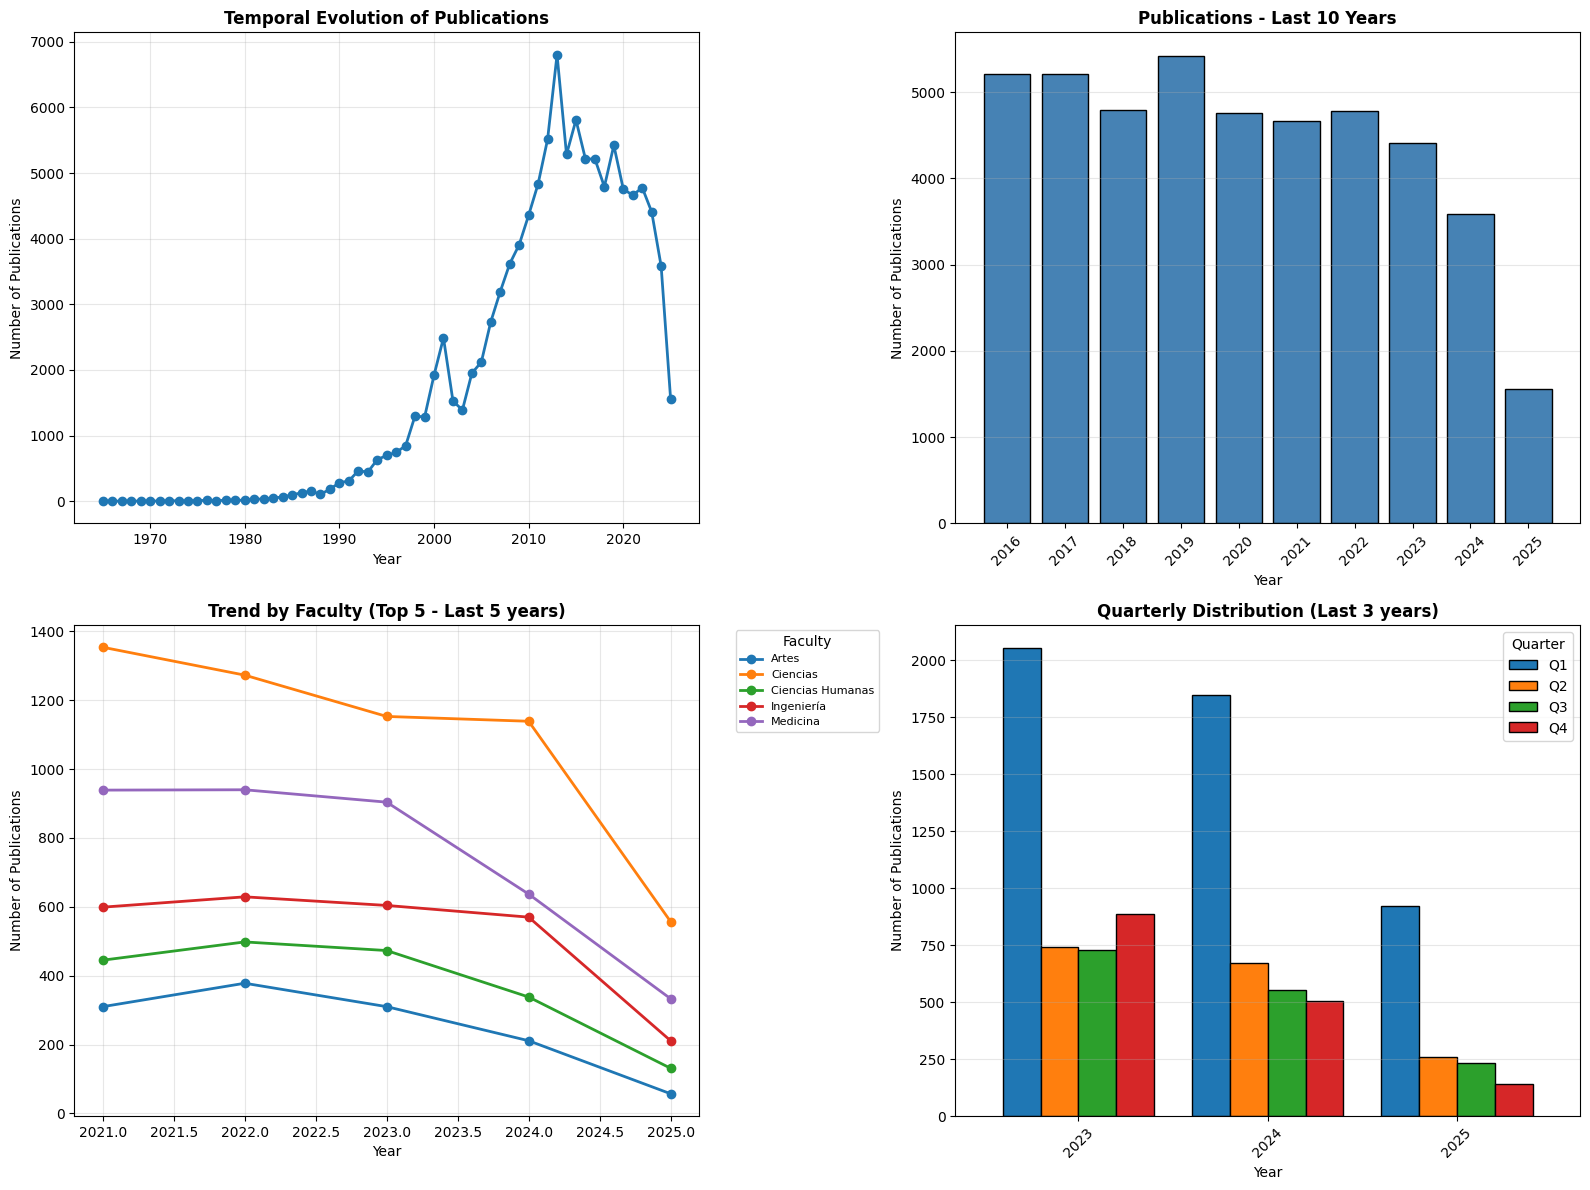


--- Seasonality by Month ---


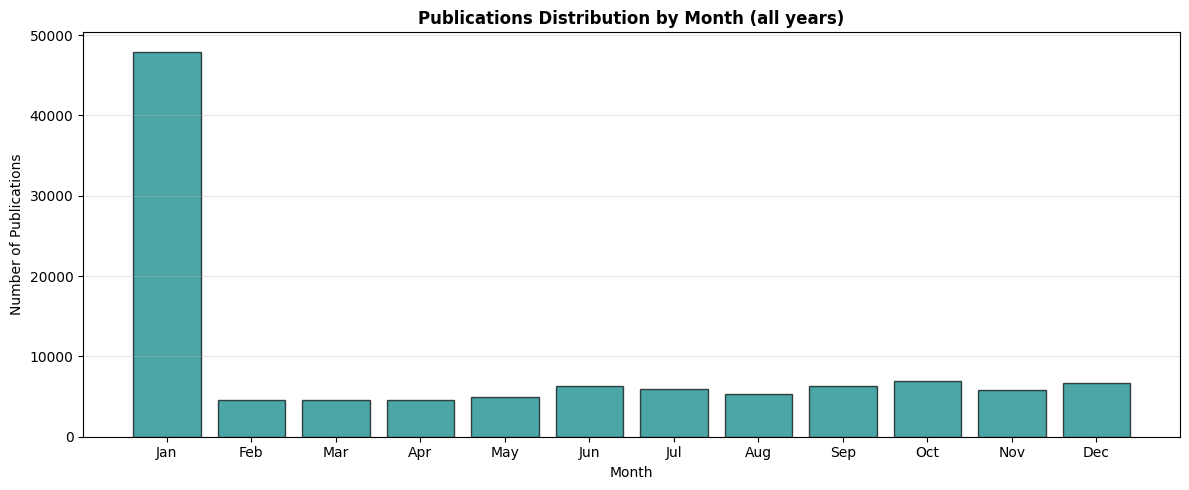


--- Growth Rate by Faculty (last 5 years) ---


,min,max,count
faculty,,,
Ciencias,2021,2025,5476
Medicina,2021,2025,3753
Ingeniería,2021,2025,2613
Ciencias Humanas,2021,2025,1885
Artes,2021,2025,1266
Ciencias Agrarias,2021,2025,914
Ciencias Económicas,2021,2025,749
Enfermería,2021,2025,742
Derecho,2021,2025,620


In [14]:
# Publications Temporal Analysis
print("="*60)
print("PUBLICATIONS TEMPORAL ANALYSIS")
print("="*60)

# Convert fecha to datetime if not done
if 'date_dt' not in locals():
    date_dt = pd.to_datetime(products_bogota["date"], errors="coerce", dayfirst=True)

# Add temporary time columns to the DataFrame
products_bogota['year'] = date_dt.dt.year
products_bogota['month'] = date_dt.dt.month
products_bogota['quarter'] = date_dt.dt.quarter

# Filter rows with valid dates
temporal_data = products_bogota[products_bogota['year'].notna()].copy()

print(f"Records with valid date: {len(temporal_data)} ({len(temporal_data)/len(products_bogota)*100:.1f}%)")
print(f"Time range: {temporal_data['year'].min():.0f} - {temporal_data['year'].max():.0f}")

# 1. Production per year
print("\n--- Annual Production ---")
annual_prod = temporal_data['year'].value_counts().sort_index()
display(annual_prod.tail(10).to_frame("publications"))

# 2. Statistics by faculty and year (Top 5 faculties)
print("\n--- Production by Faculty (last 5 years) ---")
top_faculties = temporal_data['faculty'].value_counts().head(5).index
last_5_years = temporal_data['year'].max() - 4

faculty_year = temporal_data[
    (temporal_data['faculty'].isin(top_faculties)) &
    (temporal_data['year'] >= last_5_years)
].groupby(['faculty', 'year']).size().unstack(fill_value=0)

display(faculty_year)

# 3. Growth trend
print("\n--- Trend Analysis ---")
yearly_growth = annual_prod.pct_change() * 100
print(f"Average annual growth: {yearly_growth.mean():.2f}%")
print(f"Year with highest growth: {yearly_growth.idxmax():.0f} ({yearly_growth.max():.1f}%)")
print(f"Year with highest production: {annual_prod.idxmax():.0f} ({annual_prod.max()} publications)")

# 4. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Full time series
axes[0, 0].plot(annual_prod.index, annual_prod.values, marker='o', linewidth=2)
axes[0, 0].set_title('Temporal Evolution of Publications', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Publications')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Last 10 years (bars)
last_10 = annual_prod.tail(10)
axes[0, 1].bar(last_10.index.astype(str), last_10.values, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Publications - Last 10 Years', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Publications')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Trend by faculty (Top 5, last 5 years)
faculty_year.T.plot(ax=axes[1, 0], marker='o', linewidth=2)
axes[1, 0].set_title('Trend by Faculty (Top 5 - Last 5 years)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Number of Publications')
axes[1, 0].legend(title='Faculty', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Quarterly distribution (last 3 years)
last_3_years = temporal_data['year'].max() - 2
quarter_data = temporal_data[temporal_data['year'] >= last_3_years]
trim_pivot = quarter_data.groupby(['year', 'quarter']).size().unstack(fill_value=0)
trim_pivot.plot(kind='bar', ax=axes[1, 1], width=0.8, edgecolor='black')
axes[1, 1].set_title('Quarterly Distribution (Last 3 years)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Publications')
axes[1, 1].legend(title='Quarter', labels=['Q1', 'Q2', 'Q3', 'Q4'])
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 5. Seasonality analysis (publications by month)
print("\n--- Seasonality by Month ---")
monthly_prod = temporal_data['month'].value_counts().sort_index()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, 13), [monthly_prod.get(i, 0) for i in range(1, 13)],
       color='teal', edgecolor='black', alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title('Publications Distribution by Month (all years)', fontsize=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Publications')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 6. Publication rate by faculty (last 5 years)
print("\n--- Growth Rate by Faculty (last 5 years) ---")
faculty_growth = temporal_data[
    temporal_data['year'] >= last_5_years
].groupby('faculty')['year'].agg(['min', 'max', 'count'])

display(faculty_growth.sort_values('count', ascending=False).head(10))

# Clean up temporary columns
products_bogota.drop(columns=['year', 'month', 'quarter'], inplace=True)

### 2.4.2. Correlation: Missing Descriptions vs. Publication Date

There is a systematic artifact where older publications are much more likely to lack a description because digital metadata standards weren't established until the 2000s. We analyze this by looking at description availability per decade to justify retaining older publications despite semantic sparsity.

CORRELATION: DESCRIPTIONS BY DECADE


,total_records,with_description,pct_with_description
Decade,,,
1960,15,7,46.7
1970,99,24,24.2
1980,869,137,15.8
1990,7011,943,13.5
2000,24856,6776,27.3
2010,53243,36081,67.8
2020,23742,20111,84.7


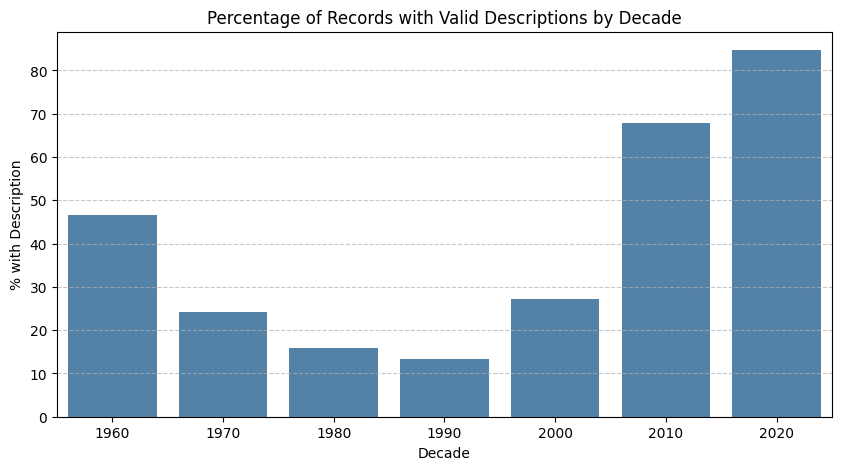

In [15]:
print("="*60)
print("CORRELATION: DESCRIPTIONS BY DECADE")
print("="*60)

# 1. Create a Decade column based on valid dates
df_temp = products_bogota.copy()
df_temp['Decade'] = date_dt.dt.year // 10 * 10
df_temp = df_temp.dropna(subset=['Decade'])

# 2. Flag records that have a usable description
df_temp['has_desc'] = df_temp['original_description'].notna() & (df_temp['original_description'].str.strip() != '') & ~df_temp['original_description'].apply(is_null_by_convention)

# 3. Aggregate
decade_correlation = df_temp.groupby('Decade').agg(
    total_records=('original_title', 'count'),
    with_description=('has_desc', 'sum')
)
decade_correlation['pct_with_description'] = (decade_correlation['with_description'] / decade_correlation['total_records']) * 100

display(decade_correlation.round(1))

# 4. Plot
plt.figure(figsize=(10, 5))
sns.barplot(
    data=decade_correlation.reset_index(), 
    x='Decade', 
    y='pct_with_description', 
    color='steelblue'
)
plt.title('Percentage of Records with Valid Descriptions by Decade')
plt.ylabel('% with Description')
plt.xlabel('Decade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The lack of description is strongly monotonic with age. We will not use publication date as a strict filter to avoid biasing against historical expertise.

## 2.5. Metadata Quality and Text Field Analysis ('original_title', 'original_description')

In [16]:
# Text columns analysis (original_title, original_description)
print("="*60)
print("TEXT COLUMNS ANALYSIS")
print("="*60)

# Titles
products_bogota['title_length'] = products_bogota['original_title'].fillna('').astype(str).str.len()
display(pd.DataFrame({
    'column': ['original_title'],
    'total': [len(products_bogota)],
    'non_null': [products_bogota['original_title'].notna().sum()],
    'empty': [(products_bogota['original_title'].fillna('').astype(str).str.strip() == '').sum()],
    'avg_length': [products_bogota['title_length'].mean()],
    'median_length': [products_bogota['title_length'].median()],
    'min_length': [products_bogota['title_length'].min()],
    'max_length': [products_bogota['title_length'].max()]
}))

# Description/Abstracts
products_bogota['desc_length'] = products_bogota['original_description'].fillna('').astype(str).str.len()
desc_non_null = products_bogota['original_description'].notna()
short_descs = (products_bogota['desc_length'] > 0) & (products_bogota['desc_length'] < 50)

display(pd.DataFrame({
    'column': ['original_description'],
    'total': [len(products_bogota)],
    'non_null': [desc_non_null.sum()],
    'empty': [(products_bogota['desc_length'] == 0).sum()],
    'very_short (<50 chars)': [short_descs.sum()],
    'avg_length': [products_bogota.loc[desc_non_null, 'desc_length'].mean()],
    'median_length': [products_bogota.loc[desc_non_null, 'desc_length'].median()],
    'min_length': [products_bogota.loc[desc_non_null, 'desc_length'].min()],
    'max_length': [products_bogota.loc[desc_non_null, 'desc_length'].max()]
}))

# Clean temporary columns
products_bogota.drop(columns=['title_length', 'desc_length'], inplace=True)

# Show examples of very short abstracts
if short_descs.sum() > 0:
    print("\nExamples of very short descriptions:")
    display(products_bogota.loc[short_descs, ['original_title', 'original_description']].head(5))

TEXT COLUMNS ANALYSIS


,column,total,non_null,empty,avg_length,median_length,min_length,max_length
0,original_title,109836,109835,1,95.878319,92.0,0,978


,column,total,non_null,empty,very_short (<50 chars),avg_length,median_length,min_length,max_length
0,original_description,109836,69928,39908,7023,1349.212747,1191.0,1,23677



Examples of very short descriptions:


,original_title,original_description
81,EFECTO DE LA VARIABILIDAD CLIMÁTICA EN PRODUCC...,No Reportado
90,VULNERABILIDAD DE ESTRUCTURAS DE CONCRETO REFO...,No Reportado
91,DISEÑO DE SISTEMA ELECTRÓNICO PARA EL MONITORE...,No Reportado
92,TÉCNICAS PARA IDENTIFICAR FALLAS ELÉCTRICAS EN...,No Reportado
94,RESISTENCIA A LA CORROSIÓN DEL RECUBRIMIENTO D...,No Reportado


In [17]:
print("="*60)
print("DATA QUALITY ANALYSIS - MISSING VALUES & CONVENTIONS")
print("="*60)

# Check each column for conventions
cols_to_check = ['original_title', 'original_description', 'language',
                 'source', 'type', 'journal_conference', 'doi', 'isbn', 'issn']

quality_summary = []
for col in cols_to_check:
    if col not in products_bogota.columns:
        continue
    real_nans = products_bogota[col].isna().sum()
    convention_nans = products_bogota[col].apply(is_null_by_convention).sum() - real_nans
    empties = (products_bogota[col].fillna('').astype(str).str.strip() == '').sum() - real_nans
    quality_summary.append({
        'Column': col,
        'Real NaNs': real_nans,
        'Empty Strings': empties,
        'Convention NaNs': convention_nans,
        'Total Effectively Null': real_nans + empties + convention_nans,
        '% Effective Null': round((real_nans + empties + convention_nans) / len(products_bogota) * 100, 2),
        'Valid Uniques': products_bogota[col].dropna().nunique()
    })

quality_summary_df = pd.DataFrame(quality_summary)
display(quality_summary_df)

# Rows with empty title
no_title_rows = products_bogota[
    products_bogota['original_title'].fillna('').astype(str).str.strip() == ''
]
print(f"\nRows without title: {len(no_title_rows)}")
display(no_title_rows[['type', 'source', 'faculty', 'original_description']].head(10))

DATA QUALITY ANALYSIS - MISSING VALUES & CONVENTIONS


,Column,Real NaNs,Empty Strings,Convention NaNs,Total Effectively Null,% Effective Null,Valid Uniques
0,original_title,1,0,0,1,0.00,104658
1,original_description,39908,0,5849,45757,41.66,59491
2,language,7733,0,0,7733,7.04,30
3,source,0,0,0,0,0.00,12
4,type,0,0,0,0,0.00,30
5,journal_conference,41852,0,0,41852,38.10,13456
6,doi,83057,0,0,83057,75.62,25188
7,isbn,100105,0,0,100105,91.14,6073
8,issn,66136,0,0,66136,60.21,9587



Rows without title: 1


,type,source,faculty,original_description
49067,Proyecto,HERMES,Ciencias Humanas,NaN


## 2.6. Linguistic Metadata Analysis ('language')

DETAILED LANGUAGE ANALYSIS

Full language distribution:


,frequency,percentage
language,,
Español,60001,54.63
Inglés,37254,33.92
NaN,7733,7.04
Portugués,1119,1.02
Galicia,1110,1.01
Indonesio,632,0.58
Francés,454,0.41
Italiano,432,0.39
Alemán,374,0.34



Records without language specified: 7733
Of these, have description: 410

Language by faculty (top 8 languages):


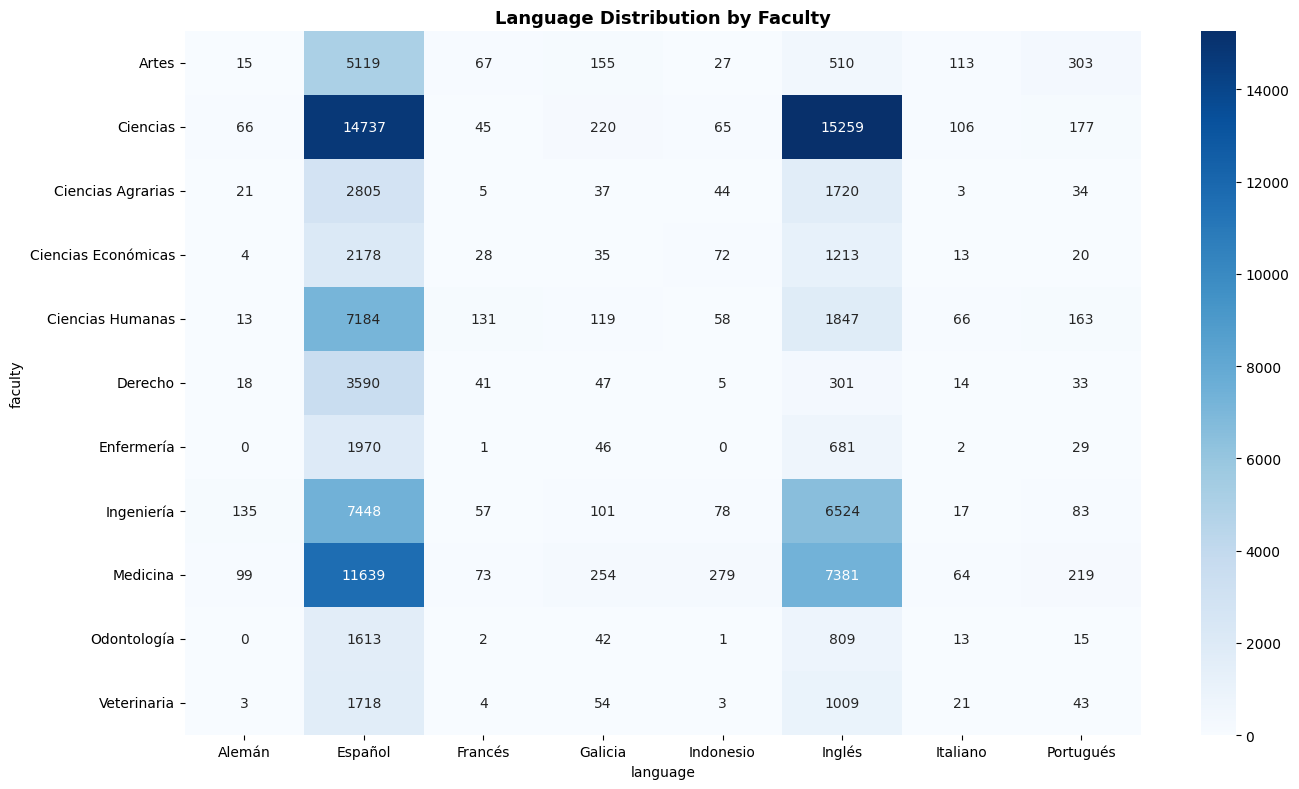


Language by production type (top 8 languages):


language,Alemán,Español,Francés,Galicia,Indonesio,Inglés,Italiano,Portugués
type,,,,,,,,
Apoyo a la investigación,0,0,0,0,0,12,0,0
Artículo de conferencia,60,1947,8,17,107,3687,10,31
Artículo de revista,167,12504,83,189,322,25863,123,197
Capítulo de libro,22,5140,97,158,28,1056,72,73
Colección científica,1,113,0,6,0,3,0,2
Comentario,0,0,0,0,0,3,1,0
Datos,5,17,7,0,1,76,1,3
Desarrollo de software,10,85,1,4,3,6,1,35
Editorial,30,103,6,1,99,305,0,2



Records with missing language (by convention): 7733
Heuristic language inference for records without language:


,count
original_title,
Español (inferido),4165
Inglés (inferido),2030
Indeterminado,1538


In [18]:
print("="*60)
print("DETAILED LANGUAGE ANALYSIS")
print("="*60)

print("\nFull language distribution:")
language_counts = products_bogota['language'].value_counts(dropna=False)
display(language_counts.to_frame("frequency").assign(
    percentage=lambda df: (df['frequency'] / len(products_bogota) * 100).round(2)
))

has_description_mask = products_bogota['original_description'].notna()
missing_language_mask = products_bogota['language'].isna()

print(f"\nRecords without language specified: {missing_language_mask.sum()}")
print(f"Of these, have description: {(missing_language_mask & has_description_mask).sum()}")

# Language vs Faculty heatmap
print("\nLanguage by faculty (top 8 languages):")
top_languages = products_bogota['language'].value_counts().head(8).index
language_faculty = products_bogota[
    products_bogota['language'].isin(top_languages)
].groupby(['faculty', 'language']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(language_faculty, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Language Distribution by Faculty', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Language vs type
print("\nLanguage by production type (top 8 languages):")
language_type = products_bogota[
    products_bogota['language'].isin(top_languages)
].groupby(['type', 'language']).size().unstack(fill_value=0)
display(language_type)

missing_language_convention_mask = products_bogota['language'].apply(is_null_by_convention)
print(f"\nRecords with missing language (by convention): {missing_language_convention_mask.sum()}")
inferred_languages = products_bogota.loc[missing_language_convention_mask, 'original_title'].apply(infer_language_heuristic)
print("Heuristic language inference for records without language:")
display(inferred_languages.value_counts().to_frame("count"))

In [19]:
products_bogota[products_bogota['language'].isna()][['original_title', 'original_description', 'faculty', 'type', 'date']]

,original_title,original_description,faculty,type,date
129,"DEVELOPMENT OF THE FUSED FILAMENT FABRICATION,...",No Reportado,Ingeniería,Tesis Doctorado,30/01/2025
752,LACAP 2024 Cover Page,NaN,Ingeniería,Editorial,01/01/2024
834,STUDY OF THE PREPARATION AND EVALUATION OF STA...,No Reportado,Ingeniería,Tesis Doctorado,27/11/2023
913,PRODUCTION OF N-BUTYL LACTATE BY REACTIVE DIST...,No Reportado,Ingeniería,Tesis Doctorado,12/09/2023
1089,MODELING AND OPTIMIZATION OF TIMBER PRODUCTION...,No Reportado,Ingeniería,Tesis Doctorado,12/04/2023
...,...,...,...,...,...
153221,MASTER OF SCIENCE EN VETERINARY MICROBILOGY,NaN,Veterinaria,Tesis Maestría,10/02/1989
153223,MASTER EN DIRECCION UNIVERSITARIA.,NaN,Veterinaria,Tesis Maestría,01/02/1989
153307,MAGISTER EN NUTRICION ANIMAL,NaN,Veterinaria,Tesis Maestría,01/06/1979
153309,MAGISTER EN PRODUCCION ANIMAL,NaN,Veterinaria,Tesis Maestría,01/01/1979


## 2.7. Categorical Structure Analysis ('type', 'source', 'faculty', 'journal_conference')

CATEGORICAL COLUMNS ANALYSIS

--- type ---
Unique categories: 30
Top 30:


,frequency
type,
Artículo de revista,41706
Tesis Maestría,17660
Ponencias en eventos especializados,10422
Proyecto,10152
Capítulo de libro,7767
Libro,6071
Artículo de conferencia,5979
Tesis Doctorado,2408
Tesis Especialización,1561


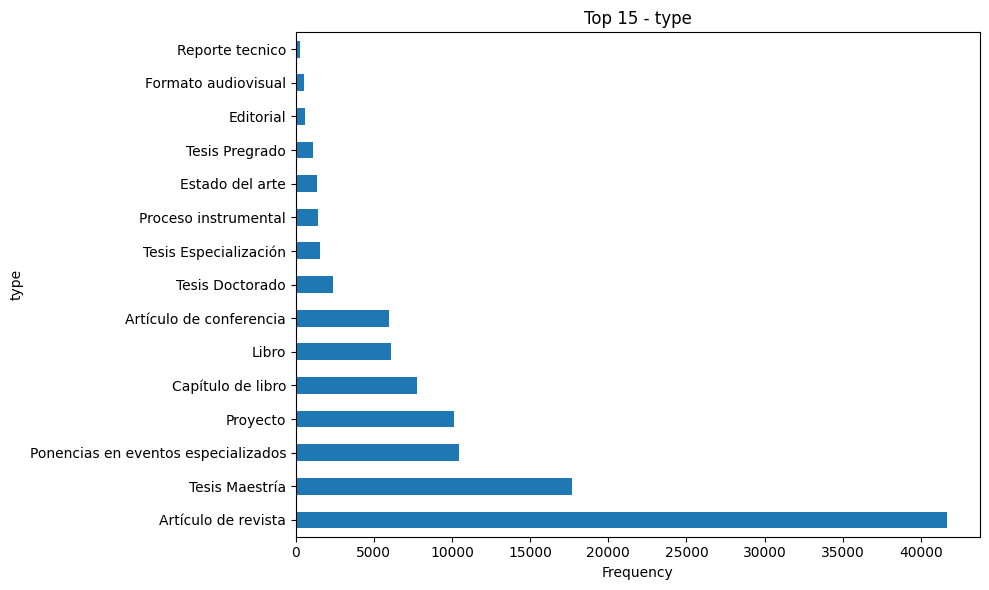


--- source ---
Unique categories: 12
Top 30:


,frequency
source,
SARA,49040
SCOPUS,23756
RepositorioUNAL,12287
HERMES,10152
CURADURIA,4359
RG,3977
RevistasUNAL,2143
WEB OF SCIENCE,2013
BibliotecasUNAL,1169


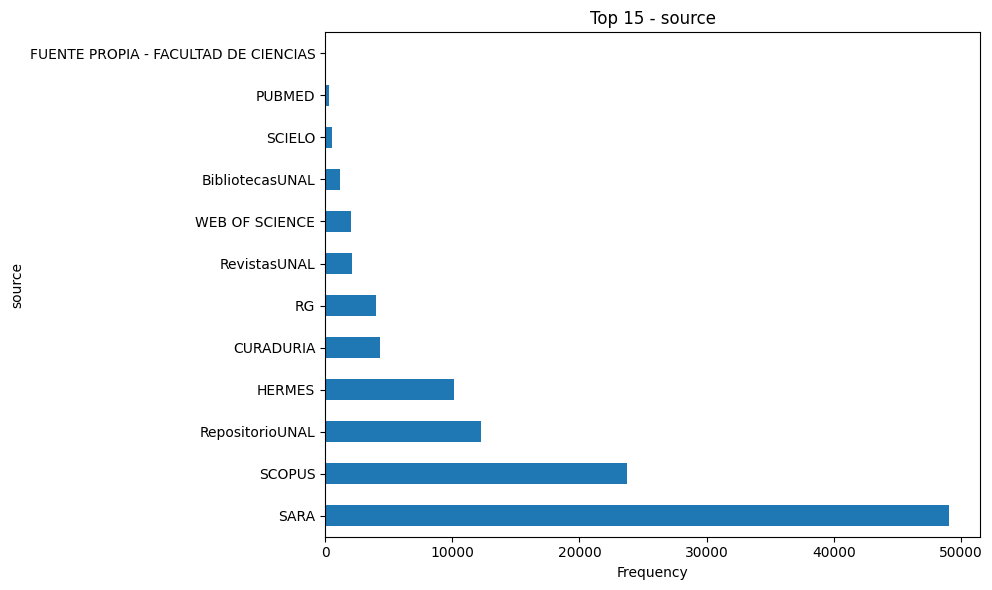


--- faculty ---
Unique categories: 11
Top 30:


,frequency
faculty,
Ciencias,33701
Medicina,21115
Ingeniería,15228
Ciencias Humanas,10415
Artes,7640
Ciencias Agrarias,4884
Derecho,4268
Ciencias Económicas,3758
Veterinaria,3256


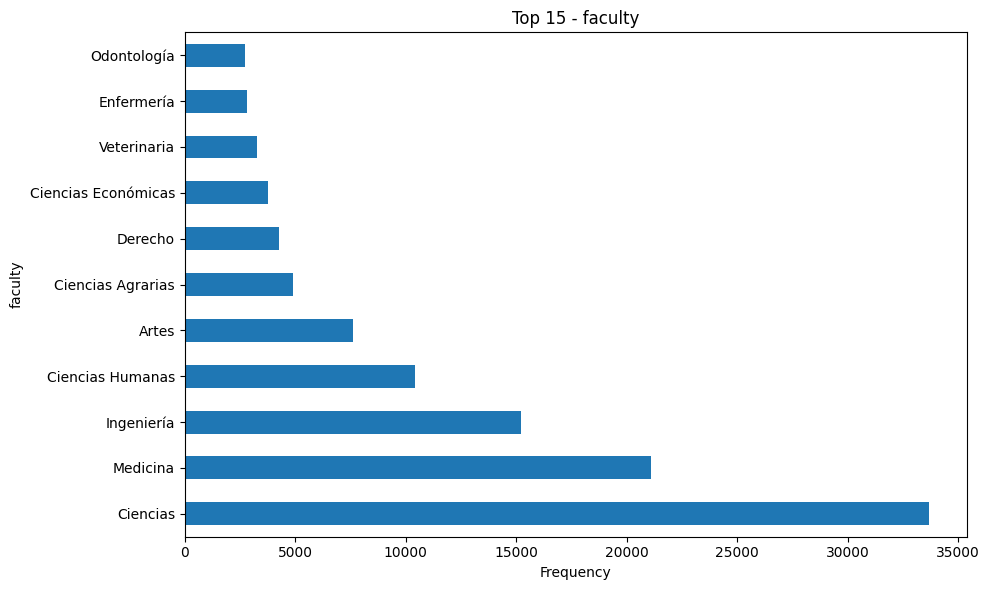


--- journal_conference ---
Unique categories: 13457
Top 30:


,frequency
journal_conference,
NaN,41852
Universidad Nacional de Colombia,12150
Revista de la Facultad de Medicína,1005
Revista Colombiana de Física,666
Biomédica,577
Agronomía Colombiana,511
Ingeniería e Investigación,493
Revista de Salud Pública,487
The Journal of High Energy Physics,444


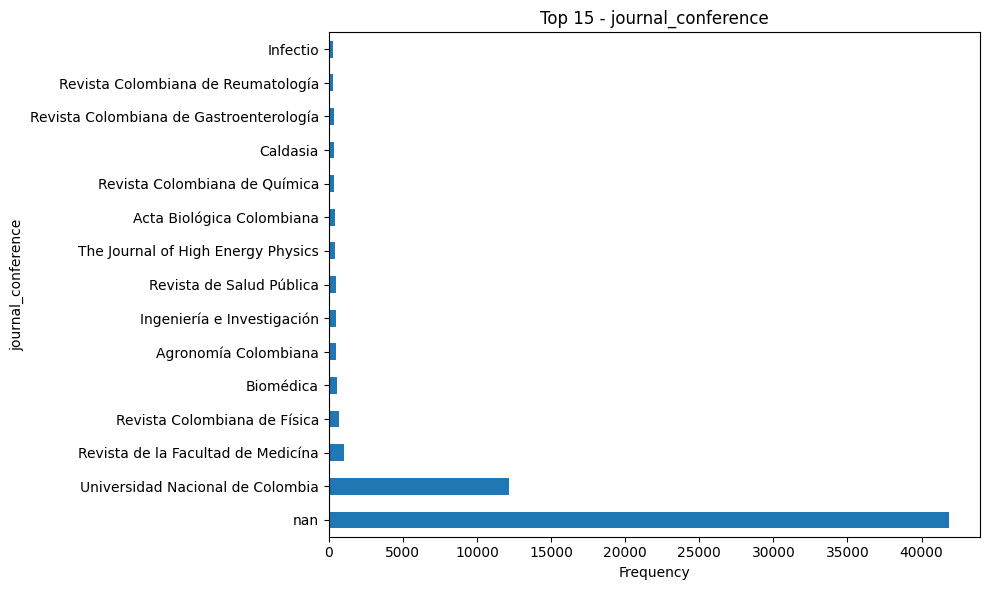

In [20]:
# Categorical columns analysis
print("="*60)
print("CATEGORICAL COLUMNS ANALYSIS")
print("="*60)

categorical_columns = ['type', 'source', 'faculty', 'journal_conference']

for col in categorical_columns:
    print(f"\n--- {col} ---")
    counts = products_bogota[col].value_counts(dropna=False)
    print(f"Unique categories: {products_bogota[col].nunique(dropna=False)}")
    print("Top 30:")
    display(counts.head(30).to_frame("frequency"))

    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    counts.head(15).plot(kind='barh', ax=ax)
    ax.set_title(f'Top 15 - {col}')
    ax.set_xlabel('Frequency')
    plt.tight_layout()
    plt.show()

RELATION: SOURCE x FACULTY x TYPE
Top sources by faculty:


faculty,Artes,Ciencias,Ciencias Agrarias,Ciencias Económicas,Ciencias Humanas,Derecho,Enfermería,Ingeniería,Medicina,Odontología,Veterinaria
source,,,,,,,,,,,
BibliotecasUNAL,111,328,45,51,134,64,46,126,174,53,37
CURADURIA,1,40,515,4,10,0,4,12,3756,15,2
HERMES,808,3422,508,304,996,507,209,1497,1182,371,348
RG,2,143,724,18,22,277,6,1133,1643,6,3
RepositorioUNAL,974,3350,433,823,1121,619,294,2227,2077,185,184
RevistasUNAL,147,753,45,102,455,130,51,166,189,66,39
SARA,5291,14114,1581,1860,6250,2475,1619,5678,6642,1509,2021
SCIELO,19,204,23,21,48,7,35,51,129,18,8
SCOPUS,245,10602,929,439,1089,86,455,4016,4895,442,558



Top sources by production type:


type,Artículo de conferencia,Artículo de revista,Capítulo de libro,Colección científica,Datos,Desarrollo de software,Editorial,Estado del arte,Formato audiovisual,Libro,...,Ponencias en eventos especializados,Posters presentados,Preimpresión,Proceso instrumental,Proyecto,Reporte tecnico,Tesis Doctorado,Tesis Especialización,Tesis Maestría,Tesis Pregrado
source,,,,,,,,,,,,,,,,,,,,,
BibliotecasUNAL,0,0,0,0,0,0,0,0,0,304,...,0,0,0,0,0,0,25,95,187,558
CURADURIA,1249,1662,681,0,0,0,0,0,0,549,...,0,0,0,0,0,210,0,0,0,0
HERMES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,10152,0,0,0,0,0
RG,745,2425,246,0,144,1,0,0,0,158,...,0,108,44,0,0,48,0,0,0,0
RepositorioUNAL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1159,906,9717,505
RevistasUNAL,0,2143,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SARA,1246,13946,6470,90,0,197,0,0,495,5036,...,10422,0,0,1425,0,0,1224,560,7756,10
SCIELO,0,563,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SCOPUS,2739,18986,370,0,0,0,480,1156,0,24,...,0,0,1,0,0,0,0,0,0,0


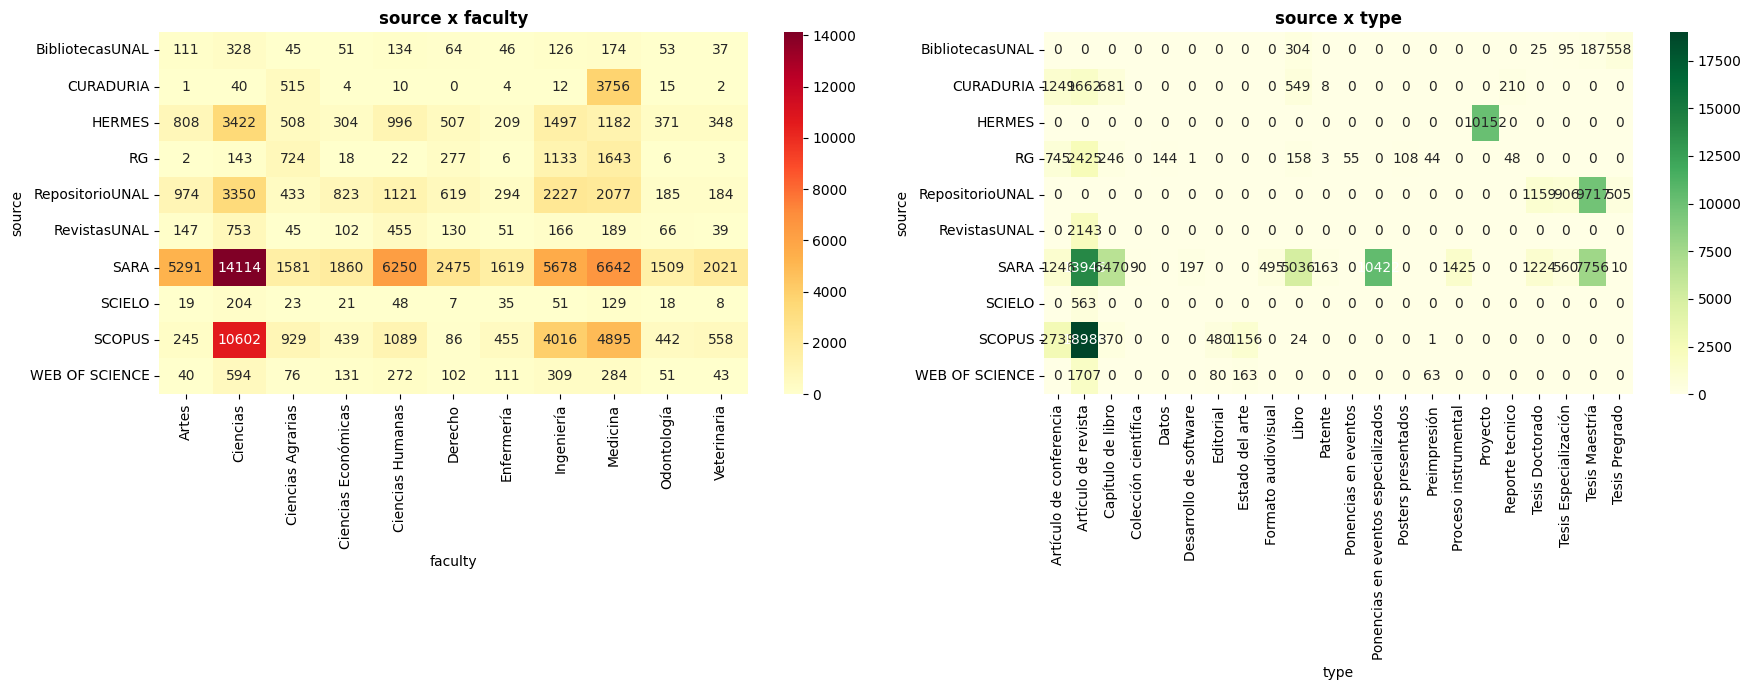

In [21]:
print("="*60)
print("RELATION: SOURCE x FACULTY x TYPE")
print("="*60)

# source vs faculty
top_sources = products_bogota['source'].value_counts().head(10).index
source_faculty = products_bogota[
    products_bogota['source'].isin(top_sources)
].groupby(['source', 'faculty']).size().unstack(fill_value=0)

print("Top sources by faculty:")
display(source_faculty)

# source vs type
source_type = products_bogota[
    products_bogota['source'].isin(top_sources)
].groupby(['source', 'type']).size().unstack(fill_value=0)

print("\nTop sources by production type:")
display(source_type)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(source_faculty, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('source x faculty', fontsize=12, fontweight='bold')
sns.heatmap(source_type, annot=True, fmt='d', cmap='YlGn', ax=axes[1])
axes[1].set_title('source x type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.8. Authorship Structure Analysis ('coauthors')

COAUTHORS ANALYSIS


count    109836.000000
mean         26.984067
std         237.097728
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max        4289.000000
Name: num_coauthors, dtype: float64


Total unique coauthor names: 99589


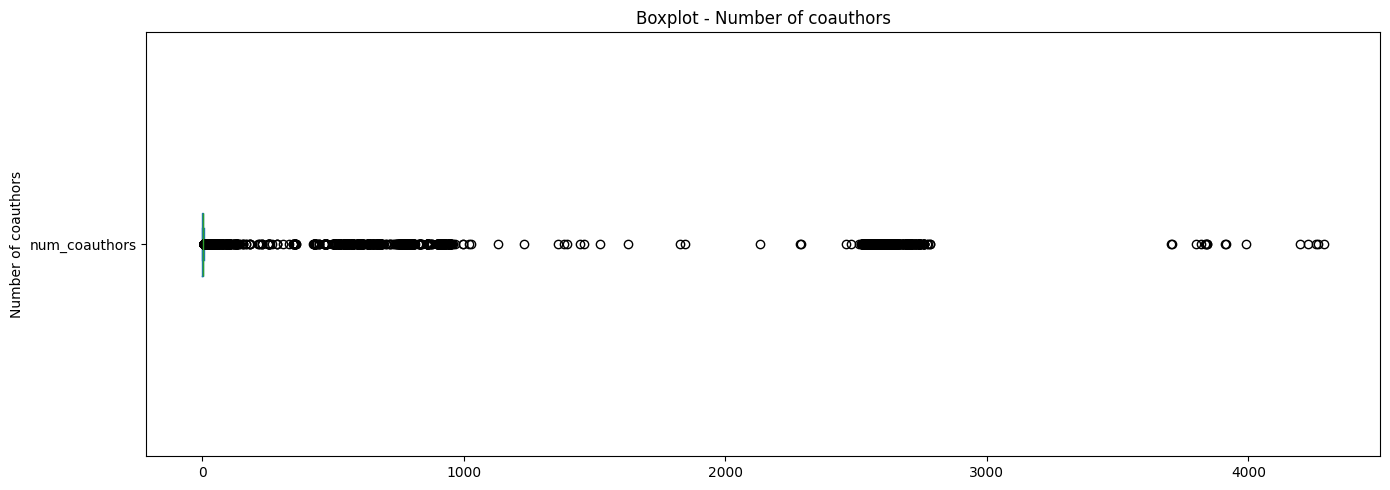

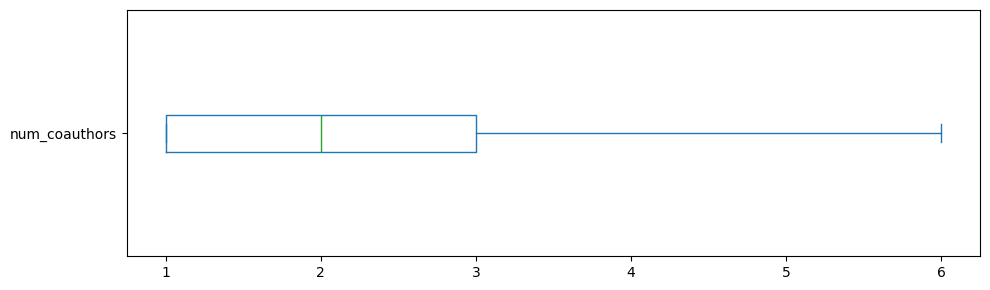

In [22]:
# Coauthors analysis
print("="*60)
print("COAUTHORS ANALYSIS")
print("="*60)

products_bogota['num_coauthors'] = products_bogota['coauthors'].apply(count_coauthors)
products_bogota.loc[products_bogota['coauthors'].isna(), 'num_coauthors'] = 0

display(products_bogota['num_coauthors'].describe())

all_coauthors = []
for coauthors in products_bogota['coauthors']:
    all_coauthors.extend(extract_coauthors(coauthors))

coauthors_counter = Counter(all_coauthors)
print(f"\nTotal unique coauthor names: {len(coauthors_counter)}")

fig, ax = plt.subplots(figsize=(14, 5))
products_bogota['num_coauthors'].plot(kind='box', vert=False, ax=ax)
ax.set_title('Boxplot - Number of coauthors')
ax.set_ylabel('Number of coauthors')
plt.tight_layout()
plt.show()

products_bogota['num_coauthors'].plot(kind='box', vert=False, figsize=(10, 3), showfliers=False)
plt.tight_layout()
plt.show()

INSPECTION OF ROWS WITH MANY COAUTHORS


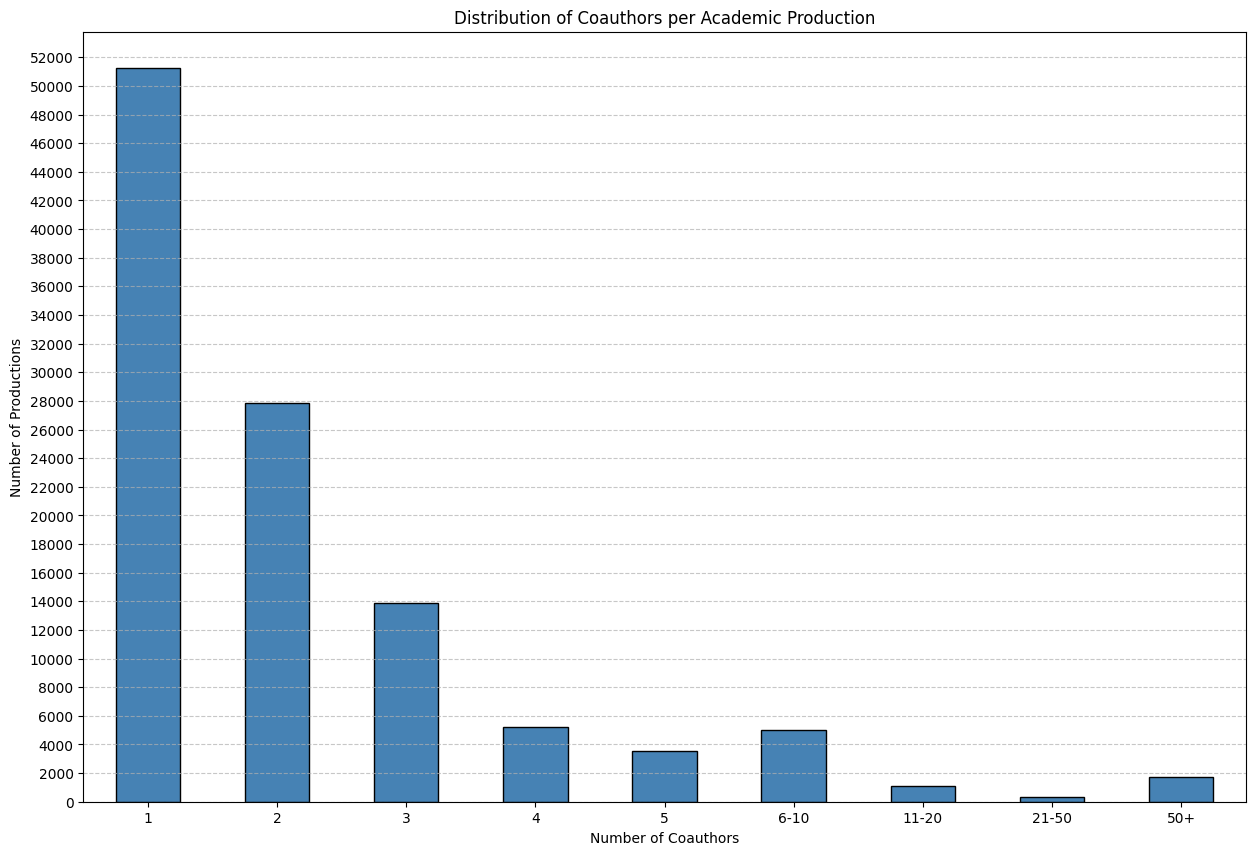

Rows with more than 50 coauthors: 1702


,original_title,original_description,journal_conference,coauthors,doi,isbn,issn,citations,language,date,type,source,link,faculty,num_coauthors
66269,Combination of the W boson polarization measur...,The combination of measurements of the W boson...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Paredes Hernande...",10.1007/JHEP08(2020)051,NaN,"10298479, 11266708",16.0,Inglés,08/01/2020,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP08(2020)051 - ...,Ciencias,4289
68028,Combinations of single-top-quark production cr...,This paper presents the combinations of single...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Paredes Hernande...",10.1007/JHEP05(2019)088,NaN,"10298479, 11266708",21.0,Inglés,05/01/2019,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP05(2019)088 - ...,Ciencias,4267
69944,Combination of inclusive and differential tt¯ ...,This paper presents combinations of inclusive ...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Castañeda Acero ...",10.1007/JHEP04(2018)033,NaN,"10298479, 11266708",10.0,Inglés,01/01/2018,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP04(2018)033 - ...,Ciencias,4259
74338,Combined Measurement of the Higgs Boson Mass i...,A measurement of the Higgs boson mass is prese...,Physical Review Letters,"Sandoval Usme Carlos Eduardo, Martinez Paez Jo...",10.1103/PhysRevLett.114.191803,NaN,"00319007, 10797114",1050.0,Inglés,14/05/2015,Artículo de revista,SCOPUS,http://dx.doi.org/10.1103/PhysRevLett.114.1918...,Ciencias,4229
72861,Measurements of the Higgs boson production and...,Combined ATLAS and CMS measurements of the Hig...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Martinez Paez Jo...",10.1007/JHEP08(2016)045,NaN,10298479,706.0,Inglés,08/01/2016,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP08(2016)045 - ...,Ciencias,4197


In [23]:
print("=" * 60)
print("INSPECTION OF ROWS WITH MANY COAUTHORS")
print("=" * 60)

# Discretization with custom bins
bins = [0, 1, 2, 3, 4, 5, 10, 20, 50, 5000]
labels = ['1', '2', '3', '4', '5', '6-10', '11-20', '21-50', '50+']

products_bogota['author_groups'] = pd.cut(products_bogota['num_coauthors'], bins=bins, labels=labels)

# Plot
ax = products_bogota['author_groups'].value_counts()[labels].plot(
    kind='bar',
    color='steelblue',
    edgecolor='black',
    figsize=(15, 10)
)

ax.set_title("Distribution of Coauthors per Academic Production")
ax.set_xlabel("Number of Coauthors")
ax.set_ylabel("Number of Productions")
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.locator_params(axis='y', nbins=30)
plt.xticks(rotation=0)
plt.show()

products_bogota.drop(columns=['author_groups'], inplace=True)

outlier_threshold = 50  # adjust as needed
outliers_coauthors = products_bogota[products_bogota['num_coauthors'] > outlier_threshold]

print(f"Rows with more than {outlier_threshold} coauthors: {len(outliers_coauthors)}")
display(outliers_coauthors.sort_values('num_coauthors', ascending=False).head())

ADDITIONAL COAUTHORS ANALYSIS BY TYPE
coauthors by production type:


,mean,median,max,count
type,,,,
Artículo de revista,67.533952,2.0,4289,41706
Estado del arte,15.893633,3.0,2641,1335
Estudio multicéntrico,11.000000,11.0,11,1
Estudio observacional,11.000000,11.0,14,2
Editorial,4.088028,1.0,923,568
Reporte de caso,4.000000,3.0,8,9
Errata,3.500000,2.0,10,8
Comentario,3.500000,3.0,5,4
Artículo de conferencia,3.445392,2.0,550,5979


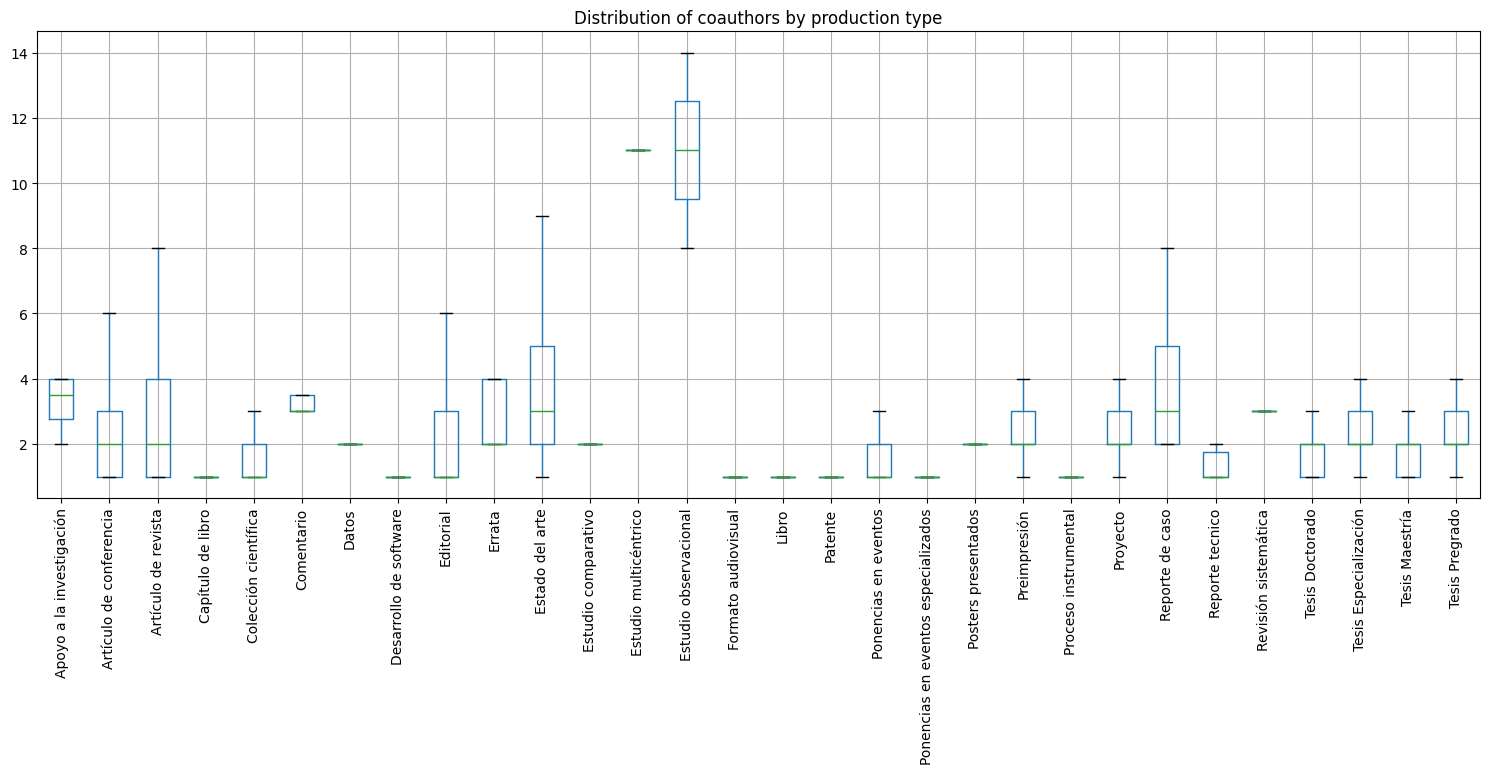

In [24]:
print("="*60)
print("ADDITIONAL COAUTHORS ANALYSIS BY TYPE")
print("="*60)

# --- A. Correlation between num_coauthors and type ---
print("coauthors by production type:")
coauthors_by_type = products_bogota.groupby('type')['num_coauthors'].agg(
    ['mean', 'median', 'max', 'count']
).sort_values('mean', ascending=False)
display(coauthors_by_type)

fig, ax = plt.subplots(figsize=(15, 8))
products_bogota.boxplot(column='num_coauthors', by='type', ax=ax,
                          showfliers=False, rot=90)
ax.set_title('Distribution of coauthors by production type')
ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 2.9. Author frequency

DISTRIBUTION ANALYSIS BY ACTIVE AUTHOR
Analyzing distribution of active professors from the 'coauthors' column...
Total unique active authors: 1934
Total mentions of active authors: 133710
Productions with at least 1 active professor: 109836/109836 (100.0%)

Statistics of productions per active author:


count    1934.000000
mean       69.136505
std        81.405972
min         1.000000
25%        19.000000
50%        43.000000
75%        89.000000
max      1024.000000
Name: count, dtype: float64


Top 20 most frequent active authors:


,productions
Sandoval Usme Carlos Eduardo,1024
Milanes Carreño Diego Alejandro,980
Sánchez Pedraza Ricardo,602
Romero Castro Edgar Eduardo,580
Giraldo Gutierrez Liliana,567
Eslava Schmalbach Javier Hernando,545
Olaya Flórez Jhon Jairo,542
Cortes Luna Jorge Alberto,520
González Osorio Fabio Augusto,516
Martinez Rodriguez Fleming,515



--- Long Tail Distribution (Active Authors) ---
Authors with 1 production: 8 (0.4%)
Authors with 2-5 productions: 96 (5.0%)
Authors with 6-10 productions: 136 (7.0%)
Authors with >10 productions: 1694 (87.6%)


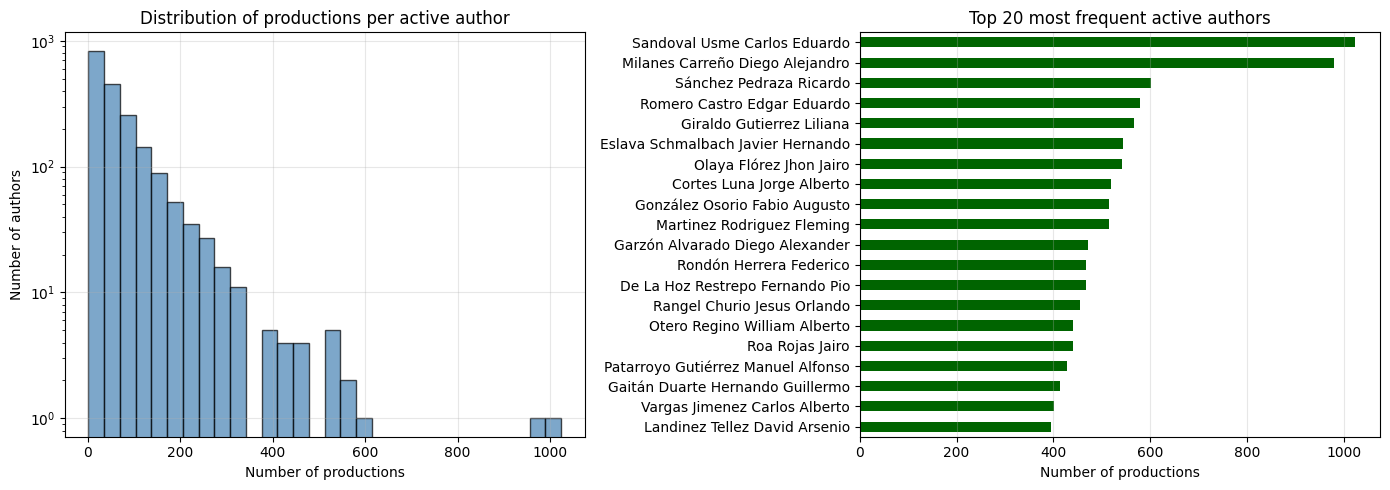

In [25]:
# Distribution by Principal Author (ACTIVE PROFESSORS ONLY)
print("="*60)
print("DISTRIBUTION ANALYSIS BY ACTIVE AUTHOR")
print("="*60)

print("Analyzing distribution of active professors from the 'coauthors' column...")

# Set of normalized active professor names for fast lookup
if 'active_professors_names' not in locals():
    active_professors_names = set(
        active_research_professors['name']
        .dropna()
        .apply(normalize_for_match)
    )

# Filter only coauthors who are active professors
active_coauthors = []
for coauthors in products_bogota['coauthors']:
    names = extract_coauthors(coauthors)
    actives = [n for n in names if normalize_for_match(n) in active_professors_names]
    active_coauthors.extend(actives)

author_counts = pd.Series(active_coauthors).value_counts()

print(f"Total unique active authors: {len(author_counts)}")
print(f"Total mentions of active authors: {len(active_coauthors)}")

# Coverage
papers_with_actives = products_bogota['coauthors'].apply(
    lambda x: has_active_professor(x, active_professors_names)
).sum()
print(f"Productions with at least 1 active professor: {papers_with_actives}/{len(products_bogota)} ({papers_with_actives/len(products_bogota)*100:.1f}%)")

print(f"\nStatistics of productions per active author:")
display(author_counts.describe())

print(f"\nTop 20 most frequent active authors:")
display(author_counts.head(20).to_frame("productions"))

# Long-tail analysis for active authors
authors_with_1 = (author_counts == 1).sum()
authors_with_2_5 = ((author_counts >= 2) & (author_counts <= 5)).sum()
authors_with_6_10 = ((author_counts >= 6) & (author_counts <= 10)).sum()
authors_with_more_10 = (author_counts > 10).sum()

print("\n--- Long Tail Distribution (Active Authors) ---")
print(f"Authors with 1 production: {authors_with_1} ({authors_with_1/len(author_counts)*100:.1f}%)")
print(f"Authors with 2-5 productions: {authors_with_2_5} ({authors_with_2_5/len(author_counts)*100:.1f}%)")
print(f"Authors with 6-10 productions: {authors_with_6_10} ({authors_with_6_10/len(author_counts)*100:.1f}%)")
print(f"Authors with >10 productions: {authors_with_more_10} ({authors_with_more_10/len(author_counts)*100:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(author_counts, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title('Distribution of productions per active author')
axes[0].set_xlabel('Number of productions')
axes[0].set_ylabel('Number of authors')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Top 20 active authors
author_counts.head(20).sort_values().plot(kind='barh', ax=axes[1], color='darkgreen')
axes[1].set_title('Top 20 most frequent active authors')
axes[1].set_xlabel('Number of productions')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


ACTIVE COAUTHORS BY FACULTY


,faculty,Productions,Unique active professors,Total active mentions,Avg mentions per professor
5,Ciencias,33701,1037,41681,40.193828
8,Medicina,21115,904,26491,29.304204
0,Ingeniería,15228,730,19108,26.175342
4,Ciencias Humanas,10415,550,11372,20.676364
1,Artes,7640,410,8550,20.853659
2,Ciencias Agrarias,4884,361,6250,17.313019
6,Derecho,4268,184,4603,25.016304
3,Ciencias Económicas,3758,280,4389,15.675000
10,Veterinaria,3256,233,3961,17.000000
7,Enfermería,2838,242,3723,15.384298


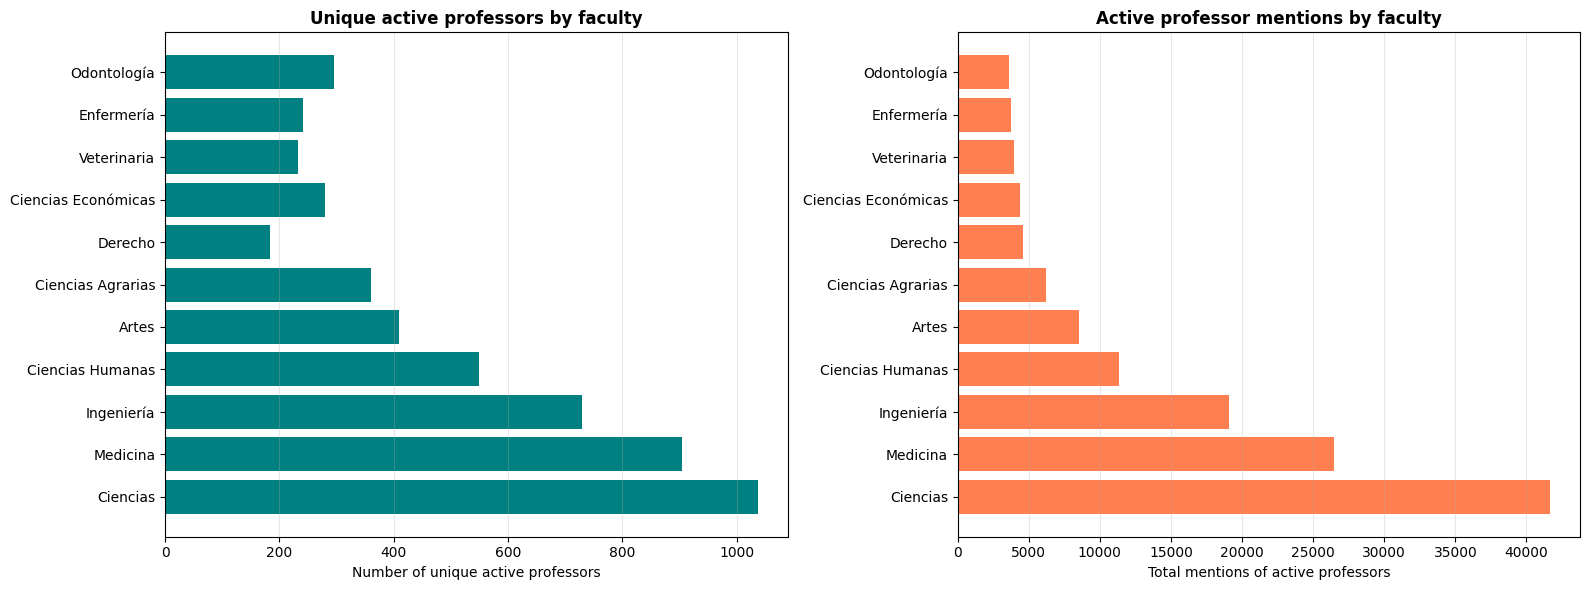

In [26]:
# Additional analysis: active coauthorship by faculty
print("\n" + "="*60)
print("ACTIVE COAUTHORS BY FACULTY")
print("="*60)

# Build table of active professors by faculty
active_by_faculty = []

for faculty in products_bogota['faculty'].dropna().unique():
    subset = products_bogota[products_bogota['faculty'] == faculty]
    
    faculty_authors = []
    for coauthors in subset['coauthors']:
        names = extract_coauthors(coauthors)
        actives = [n for n in names if normalize_for_match(n) in active_professors_names]
        faculty_authors.extend(actives)
    
    if len(faculty_authors) > 0:
        counts = pd.Series(faculty_authors).value_counts()
        active_by_faculty.append({
            'faculty': faculty,
            'Productions': len(subset),
            'Unique active professors': len(counts),
            'Total active mentions': len(faculty_authors),
            'Avg mentions per professor': counts.mean()
        })

active_faculty_df = pd.DataFrame(active_by_faculty).sort_values('Total active mentions', ascending=False)
display(active_faculty_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: unique active professors by faculty
axes[0].barh(active_faculty_df['faculty'], active_faculty_df['Unique active professors'], color='teal')
axes[0].set_xlabel('Number of unique active professors')
axes[0].set_title('Unique active professors by faculty', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Chart 2: total active mentions by faculty
axes[1].barh(active_faculty_df['faculty'], active_faculty_df['Total active mentions'], color='coral')
axes[1].set_xlabel('Total mentions of active professors')
axes[1].set_title('Active professor mentions by faculty', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 2.10. Topic modeling feasibility

In [27]:
# --- Density of text fields: useful for modeling feasibility ---
print("\nFeasibility for Topic Modeling:")
has_desc = products_bogota['original_description'].apply(
    lambda x: not is_null_by_convention(x) and len(str(x).strip()) >= 50
)
has_title = products_bogota['original_title'].apply(
    lambda x: not is_null_by_convention(x) and len(str(x).strip()) > 3
)

print(f"Records with usable description (≥50 chars): {has_desc.sum()} ({has_desc.mean()*100:.1f}%)")
print(f"Records with usable title: {has_title.sum()} ({has_title.mean()*100:.1f}%)")
print(f"Records with both: {(has_desc & has_title).sum()} ({(has_desc & has_title).mean()*100:.1f}%)")
print(f"Title only available: {(~has_desc & has_title).sum()}")


Feasibility for Topic Modeling:
Records with usable description (≥50 chars): 62905 (57.3%)
Records with usable title: 109825 (100.0%)
Records with both: 62903 (57.3%)
Title only available: 46922


## 2.11. Text Preprocessing Analysis

This section demonstrates the text preprocessing functions defined earlier and shows their effect on actual data. 

In [28]:
print("="*60)
print("TEXT PREPROCESSING EXAMPLE")
print("="*60)

# Select one example with a valid description
example = products_bogota[
    products_bogota['original_description'].notna() &
    (products_bogota['original_description'].str.len() > 100)
].sample(1, random_state=42).iloc[0]

# Title
title_orig = example['original_title']
title_clean = preprocess_text_full(title_orig)

print(f"\n📌 TITLE:")
print(f"Original: {title_orig}")
print(f"Processed: {title_clean}")
print(f"Tokens: {len(str(title_orig).split())} → {len(title_clean.split())}")

# Description
desc_orig = str(example['original_description'])[:200]
desc_clean = preprocess_text_full(example['original_description'])

print(f"\n📝 DESCRIPTION (first 200 chars):")
print(f"Original: {desc_orig}...")
print(f"Processed: {desc_clean[:200]}...")
print(f"Total tokens: {len(str(example['original_description']).split())} → {len(desc_clean.split())}")

if example['language']:
    print(f"language: {example['language']}")
if example['faculty']:
    print(f"faculty: {example['faculty']}")

TEXT PREPROCESSING EXAMPLE

📌 TITLE:
Original: PERICARDITIS Y OTROS TRASTORNOS NO CARDIACOS
Processed: pericarditis trastornos cardiacos
Tokens: 6 → 3

📝 DESCRIPTION (first 200 chars):
Original: El capítulo realiza una profundización en aspectos electrocardiográficos de la pericarditis y de otras patologías no cardiacas, en las cuales los hallazgos del electrocardiograma han sido utilizados c...
Processed: capitulo realiza profundizacion aspectos electrocardiograficos pericarditis patologias cardiacas hallazgos electrocardiograma sido utilizados clinicamente ataque cerebrovacular trastornos sericos pota...
Total tokens: 40 → 20
language: Español
faculty: Medicina


In [29]:
print("\n" + "="*70)
print("TOKENS COMPARISON: RAW vs PREPROCESSED")
print("="*70)

# Apply preprocessing to titles and descriptions
products_with_text = products_bogota[
    products_bogota['original_title'].notna()
].copy()

products_with_text['title_tokens_original'] = products_with_text['original_title'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)
products_with_text['title_processed'] = products_with_text['original_title'].apply(preprocess_text_full)
products_with_text['title_tokens_clean'] = products_with_text['title_processed'].apply(
    lambda x: len(str(x).split()) if x else 0
)

products_with_desc = products_bogota[
    products_bogota['original_description'].notna()
].copy()
products_with_desc['desc_tokens_original'] = products_with_desc['original_description'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)
products_with_desc['desc_processed'] = products_with_desc['original_description'].apply(preprocess_text_full)
products_with_desc['desc_tokens_clean'] = products_with_desc['desc_processed'].apply(
    lambda x: len(str(x).split()) if x else 0
)

# ===== TITLES =====
orig_title_total = int(products_with_text['title_tokens_original'].sum())
proc_title_total = int(products_with_text['title_tokens_clean'].sum())
red_title_abs = orig_title_total - proc_title_total
red_title_pct = (red_title_abs / orig_title_total * 100) if orig_title_total > 0 else 0.0

print("\n📘 TITLES")
print(f"Records analyzed: {len(products_with_text):,}")
print(f"TOTAL TOKENS RAW: {orig_title_total:,}")
print(f"TOTAL TOKENS PREPROCESSED:   {proc_title_total:,}")
print(f"ABSOLUTE DIFFERENCE:            {red_title_abs:,} tokens")
print(f"PERCENT REDUCTION:           {red_title_pct:.2f}%")
print(f"Average per record:          {products_with_text['title_tokens_original'].mean():.2f} → {products_with_text['title_tokens_clean'].mean():.2f}")

# ===== DESCRIPTIONS =====
orig_desc_total = int(products_with_desc['desc_tokens_original'].sum())
proc_desc_total = int(products_with_desc['desc_tokens_clean'].sum())
red_desc_abs = orig_desc_total - proc_desc_total
red_desc_pct = (red_desc_abs / orig_desc_total * 100) if orig_desc_total > 0 else 0.0

print("\n📝 DESCRIPTIONS")
print(f"Records analyzed: {len(products_with_desc):,}")
print(f"TOTAL TOKENS RAW: {orig_desc_total:,}")
print(f"TOTAL TOKENS PREPROCESSED:   {proc_desc_total:,}")
print(f"ABSOLUTE DIFFERENCE:            {red_desc_abs:,} tokens")
print(f"PERCENT REDUCTION:           {red_desc_pct:.2f}%")
print(f"Average per record:          {products_with_desc['desc_tokens_original'].mean():.2f} → {products_with_desc['desc_tokens_clean'].mean():.2f}")

# Compact summary table
tokens_summary = pd.DataFrame([
    {
        'Field': 'Title',
        'Records': len(products_with_text),
        'Total raw': orig_title_total,
        'Total preprocessed': proc_title_total,
        'Difference': red_title_abs,
        '% reduction': round(red_title_pct, 2)
    },
    {
        'Field': 'Description',
        'Records': len(products_with_desc),
        'Total raw': orig_desc_total,
        'Total preprocessed': proc_desc_total,
        'Difference': red_desc_abs,
        '% reduction': round(red_desc_pct, 2)
    }
])

print("\n TABULAR SUMMARY")
display(tokens_summary)

# Edge cases
print("\n⚠️ PROBLEMATIC CASES AFTER PREPROCESSING")
titles_empty_post = int((products_with_text['title_tokens_clean'] == 0).sum())
print(f"Titles that became empty: {titles_empty_post:,}")

descs_empty_post = int((products_with_desc['desc_tokens_clean'] == 0).sum())
print(f"Descriptions that became empty: {descs_empty_post:,}")

# Clean temporary columns
products_with_text.drop(columns=['title_tokens_original', 'title_processed', 'title_tokens_clean'], inplace=True)
products_with_desc.drop(columns=['desc_tokens_original', 'desc_processed', 'desc_tokens_clean'], inplace=True)


TOKENS COMPARISON: RAW vs PREPROCESSED

📘 TITLES
Records analyzed: 109,835
TOTAL TOKENS RAW: 1,491,281
TOTAL TOKENS PREPROCESSED:   863,657
ABSOLUTE DIFFERENCE:            627,624 tokens
PERCENT REDUCTION:           42.09%
Average per record:          13.58 → 7.86

📝 DESCRIPTIONS
Records analyzed: 69,928
TOTAL TOKENS RAW: 14,136,685
TOTAL TOKENS PREPROCESSED:   7,056,306
ABSOLUTE DIFFERENCE:            7,080,379 tokens
PERCENT REDUCTION:           50.09%
Average per record:          202.16 → 100.91

 TABULAR SUMMARY


,Field,Records,Total raw,Total preprocessed,Difference,% reduction
0,Title,109835,1491281,863657,627624,42.09
1,Description,69928,14136685,7056306,7080379,50.09



⚠️ PROBLEMATIC CASES AFTER PREPROCESSING
Titles that became empty: 90
Descriptions that became empty: 908


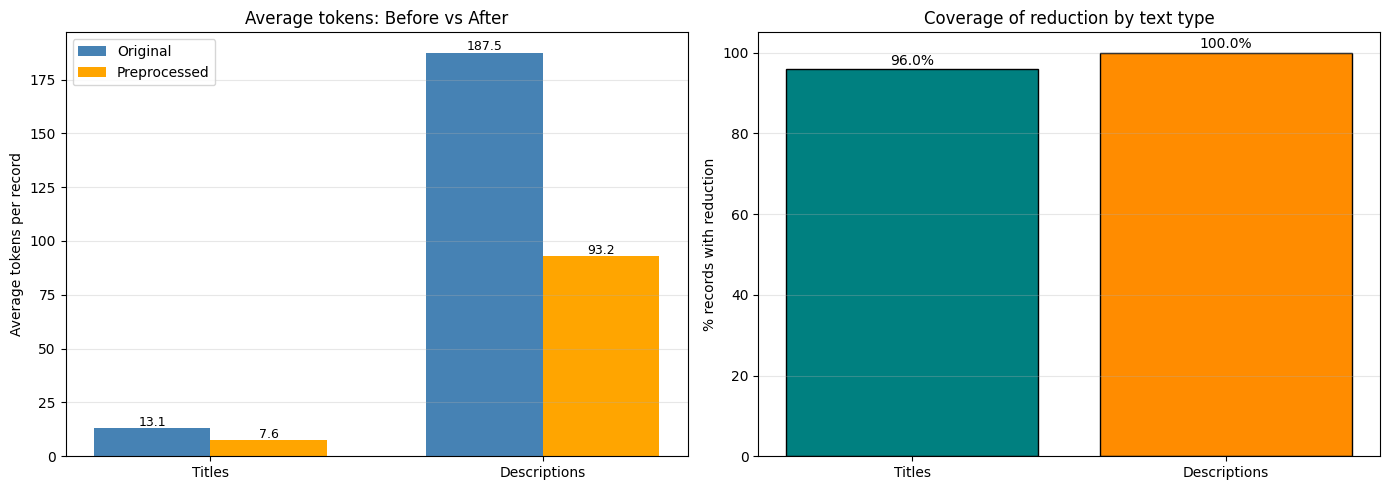


VALIDATION ORIGINAL vs PREPROCESSED DIFFERENCE
Titles - average reduction: 41.7%
Titles - % records with reduction: 96.0%
Descriptions - average reduction: 50.3%
Descriptions - % records with reduction: 100.0%


,Field,Sample,Avg original tokens,Avg preprocessed tokens,Avg reduction (%),% records reduced
0,Titles,500,13.05,7.61,41.70,96.0
1,Descriptions,300,187.54,93.16,50.33,100.0


In [30]:
# Visualization of token reduction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_titles_base = products_bogota[products_bogota['original_title'].notna()].copy()
sample_titles = sample_titles_base.sample(
    min(500, len(sample_titles_base)),
    random_state=42
)

sample_desc_base = products_bogota[products_bogota['original_description'].notna()].copy()
sample_desc = sample_desc_base.sample(
    min(300, len(sample_desc_base)),
    random_state=42
)

titles_orig_tokens = sample_titles['original_title'].apply(lambda x: len(str(x).split()))
titles_clean_tokens = sample_titles['original_title'].apply(preprocess_text_full).apply(lambda x: len(str(x).split()))
delta_titles = titles_orig_tokens - titles_clean_tokens

desc_orig_tokens = sample_desc['original_description'].apply(lambda x: len(str(x).split()))
desc_clean_tokens = sample_desc['original_description'].apply(preprocess_text_full).apply(lambda x: len(str(x).split()))
delta_desc = desc_orig_tokens - desc_clean_tokens

# =========================
# 1) AVERAGE BARS BEFORE vs AFTER
# =========================
labels = ['Titles', 'Descriptions']
avg_orig = [titles_orig_tokens.mean(), desc_orig_tokens.mean()]
avg_clean = [titles_clean_tokens.mean(), desc_clean_tokens.mean()]
x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, avg_orig, width, label='Original', color='steelblue')
axes[0].bar(x + width/2, avg_clean, width, label='Preprocessed', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Average tokens per record')
axes[0].set_title('Average tokens: Before vs After')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_orig):
    axes[0].text(i - width/2, v + 1, f'{v:.1f}', ha='center', fontsize=9)
for i, v in enumerate(avg_clean):
    axes[0].text(i + width/2, v + 1, f'{v:.1f}', ha='center', fontsize=9)

# =========================
# 2) % OF RECORDS THAT REDUCE
# =========================
pct_docs_reduced_titles = (delta_titles > 0).mean() * 100
pct_docs_reduced_desc = (delta_desc > 0).mean() * 100

axes[1].bar(
    ['Titles', 'Descriptions'],
    [pct_docs_reduced_titles, pct_docs_reduced_desc],
    color=['teal', 'darkorange'],
    edgecolor='black'
)
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('% records with reduction')
axes[1].set_title('Coverage of reduction by text type')
axes[1].grid(axis='y', alpha=0.3)

axes[1].text(0, pct_docs_reduced_titles + 1, f'{pct_docs_reduced_titles:.1f}%', ha='center')
axes[1].text(1, pct_docs_reduced_desc + 1, f'{pct_docs_reduced_desc:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# =========================
# NUMERIC SUMMARY
# =========================
pct_reduction_titles = (1 - titles_clean_tokens.mean() / titles_orig_tokens.mean()) * 100
pct_reduction_desc = (1 - desc_clean_tokens.mean() / desc_orig_tokens.mean()) * 100

print(f"\nVALIDATION ORIGINAL vs PREPROCESSED DIFFERENCE")
print(f"Titles - average reduction: {pct_reduction_titles:.1f}%")
print(f"Titles - % records with reduction: {pct_docs_reduced_titles:.1f}%")
print(f"Descriptions - average reduction: {pct_reduction_desc:.1f}%")
print(f"Descriptions - % records with reduction: {pct_docs_reduced_desc:.1f}%")

summary_difference = pd.DataFrame([
    {
        'Field': 'Titles',
        'Sample': len(sample_titles),
        'Avg original tokens': round(titles_orig_tokens.mean(), 2),
        'Avg preprocessed tokens': round(titles_clean_tokens.mean(), 2),
        'Avg reduction (%)': round(pct_reduction_titles, 2),
        '% records reduced': round(pct_docs_reduced_titles, 2)
    },
    {
        'Field': 'Descriptions',
        'Sample': len(sample_desc),
        'Avg original tokens': round(desc_orig_tokens.mean(), 2),
        'Avg preprocessed tokens': round(desc_clean_tokens.mean(), 2),
        'Avg reduction (%)': round(pct_reduction_desc, 2),
        '% records reduced': round(pct_docs_reduced_desc, 2)
    }
])

display(summary_difference)

## 2.12. Deep Text Analysis (Word Clouds & Token Statistics)

This section provides a deeper analysis of the textual content, focusing on the most frequent words, word clouds by language and faculty, and text quality metrics.

### 2.12.1. Word Clouds

Word cloud: with and without generic terms
Valid records (original cloud): 108730
Valid records (informative cloud): 108730
Terms removed by automatic DF filter (DF >= 12%): 0


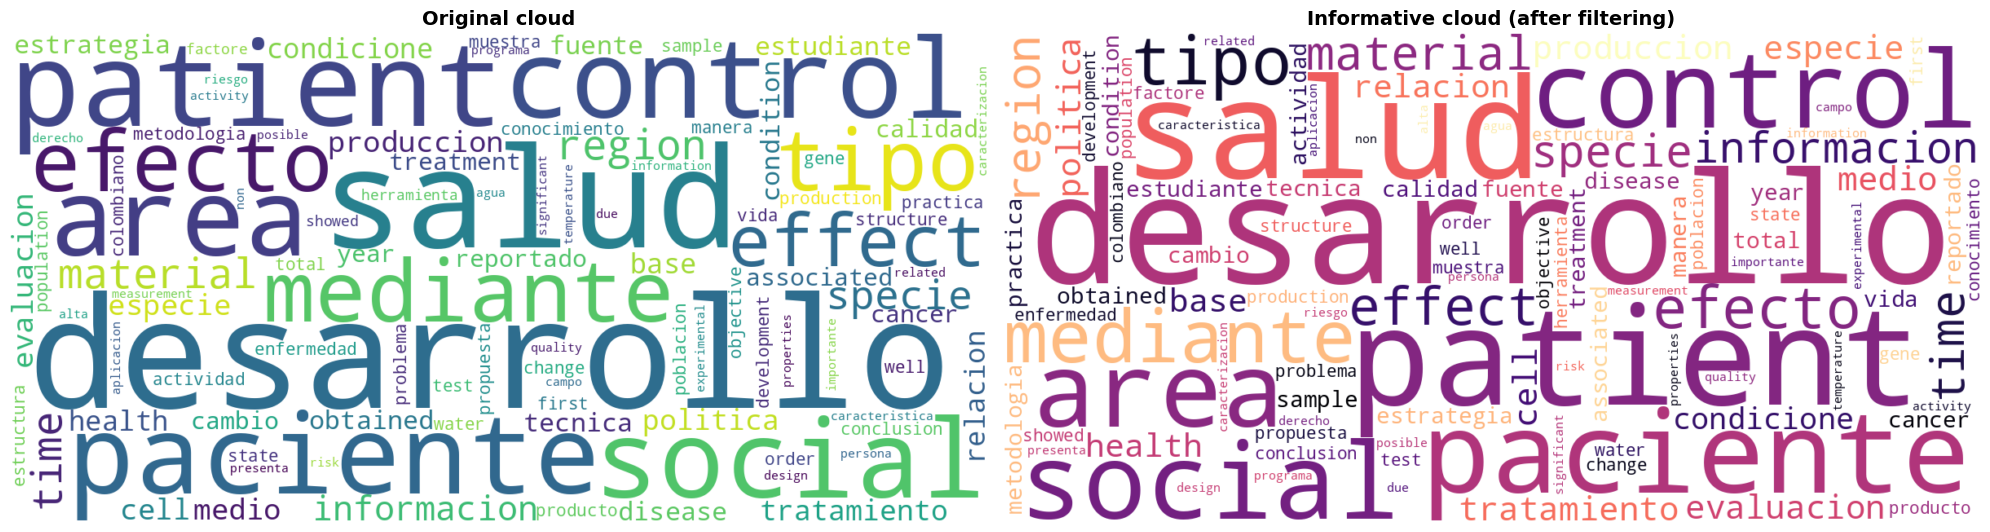

In [31]:
print("="*60)
print("Word cloud: with and without generic terms")
print("="*60)

# =========================
# 1) Build base text
# =========================
base_text = products_bogota.apply(
    lambda row: f"{str(row['original_title']) if pd.notna(row['original_title']) else ''} "
                f"{str(row['original_description']) if pd.notna(row['original_description']) else ''}",
    axis=1
)

base_text = base_text.apply(preprocess_text_full)
base_text = base_text[base_text.str.len() > 10].copy()

# =========================
# 2) Automatic document-frequency filtering
# =========================
df_threshold = 0.12

doc_freq = Counter()

for txt in base_text:
    tokens = set(txt.split())
    doc_freq.update(tokens)

n_docs = len(base_text)

auto_df_stopwords = {
    tok for tok, df in doc_freq.items()
    if (df / n_docs) >= df_threshold and len(tok) >= 2
}

# =========================
# 3) Informative text (apply thematic + automatic stopwords)
# =========================
def clean_all(text):
    return remove_stopwords(text, stopwords=STOPWORDS_ALL | auto_df_stopwords)

informative_text = base_text.apply(clean_all)
informative_text = informative_text[informative_text.str.len() > 10].copy()

print(f"Valid records (original cloud): {len(base_text)}")
print(f"Valid records (informative cloud): {len(informative_text)}")
print(f"Terms removed by automatic DF filter (DF >= {df_threshold:.0%}): {len(auto_df_stopwords)}")

# =========================
# 5) Generate clouds
# =========================
global_text_original = " ".join(base_text)
global_text_informative = " ".join(informative_text)

wordcloud_original = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    collocations=False
).generate(global_text_original)

wordcloud_informative = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='magma',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    collocations=False
).generate(global_text_informative)

# =========================
# 6) Visualization
# =========================
fig, axes = plt.subplots(1, 2, figsize=(20,7))

axes[0].imshow(wordcloud_original, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Original cloud', fontsize=14, fontweight='bold')

axes[1].imshow(wordcloud_informative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Informative cloud (after filtering)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

WORD CLOUDS BY FACULTY

Publications with valid text: 108721
Ciencias: 33459 publications
Medicina: 20951 publications
Ingeniería: 15134 publications


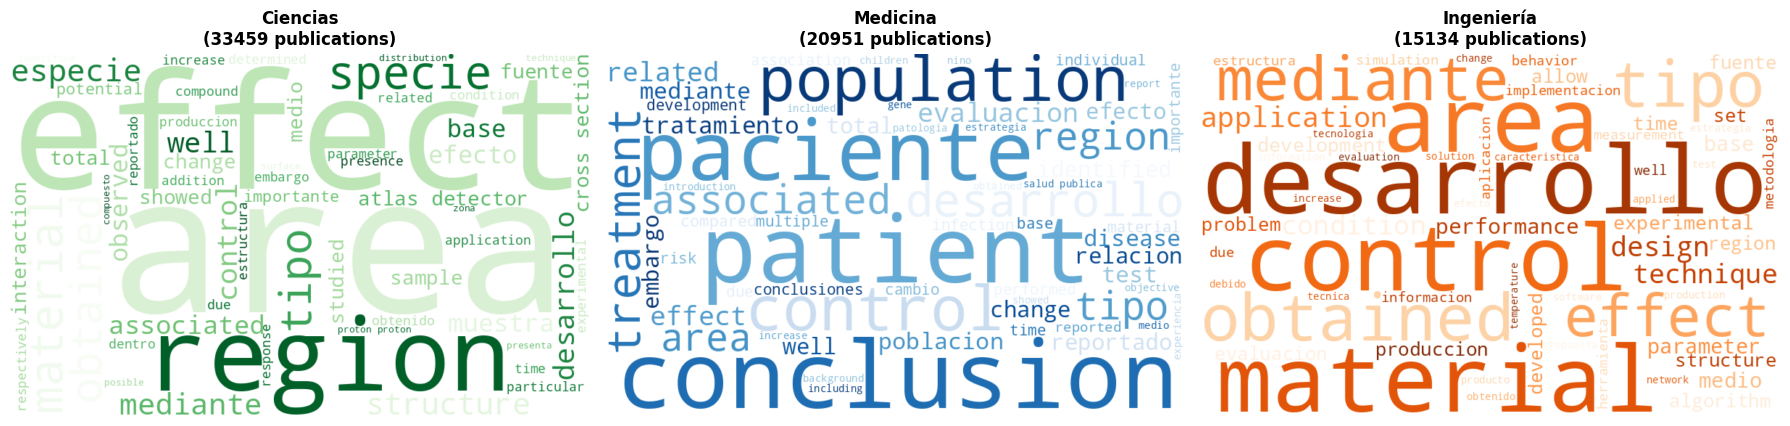

In [32]:
# ==========================================================
# NUBES DE PALABRAS POR FACULTAD (TOP 3) 
# ==========================================================

print("="*60)
print("WORD CLOUDS BY FACULTY")
print("="*60)

# ----------------------------------------------------------
# 1. Build combined text
# ----------------------------------------------------------
products_bogota['full_text'] = (
    products_bogota['original_title'].fillna('').astype(str) + " " +
    products_bogota['original_description'].fillna('').astype(str)
)

# ----------------------------------------------------------
# 2. Apply preprocessing pipeline
# ----------------------------------------------------------
products_bogota['processed_text'] = products_bogota['full_text'].apply(
    lambda t: preprocess_text_full(
        t,
        lowercase=True,
        remove_accents=True,
        min_token_length=3,
        remove_numbers=True,
        remove_stopwords_flag=True
    )
)

# ----------------------------------------------------------
# 3. Filter valid texts
# ----------------------------------------------------------
valid_texts = products_bogota[
    products_bogota['processed_text'].notna() &
    (products_bogota['processed_text'].str.len() > 10)
].copy()

print(f"\nPublications with valid text: {len(valid_texts)}")

# ----------------------------------------------------------
# 4. Select the 3 faculties with the most publications
# ----------------------------------------------------------
top_faculties = valid_texts['faculty'].value_counts().head(3).index

texts_by_faculty = {}

for faculty in top_faculties:

    subset = valid_texts[valid_texts['faculty'] == faculty]

    texts = subset['processed_text']

    filtered_texts = texts.apply(
        lambda t: remove_stopwords(t, stopwords=STOPWORDS_ALL | auto_df_stopwords)
    )

    filtered_texts = filtered_texts[filtered_texts.str.len() > 10]

    if len(filtered_texts) > 0:
        texts_by_faculty[faculty] = " ".join(filtered_texts)

    print(f"{faculty}: {len(filtered_texts)} publications")

# ----------------------------------------------------------
# 5. Generate word clouds
# ----------------------------------------------------------
num_faculties = len(texts_by_faculty)

fig, axes = plt.subplots(1, num_faculties, figsize=(6 * num_faculties, 5))

if num_faculties == 1:
    axes = [axes]

colormaps = ['Greens', 'Blues', 'Oranges']

for idx, (faculty, text) in enumerate(texts_by_faculty.items()):

    wordcloud = WordCloud(
        width=800,
        height=500,
        background_color='white',
        colormap=colormaps[idx % len(colormaps)],
        max_words=60,
        relative_scaling=0.5,
        min_font_size=10
    ).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')

    total_pub = len(valid_texts[valid_texts["faculty"] == faculty])

    axes[idx].set_title(
        f"{faculty}\n({total_pub} publications)",
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

MOST FREQUENT WORDS ANALYSIS

Documents analyzed: 108721

Total tokens processed: 7,787,006
Unique tokens: 230,647

TOP 30 MOST FREQUENT WORDS


,Word,Frequency,%
0,desarrollo,16361,0.210
1,salud,13764,0.177
2,social,12509,0.161
3,control,11978,0.154
4,mediante,11037,0.142
5,patients,10783,0.138
6,pacientes,9996,0.128
7,tipo,8936,0.115
8,species,8781,0.113
9,informacion,8378,0.108


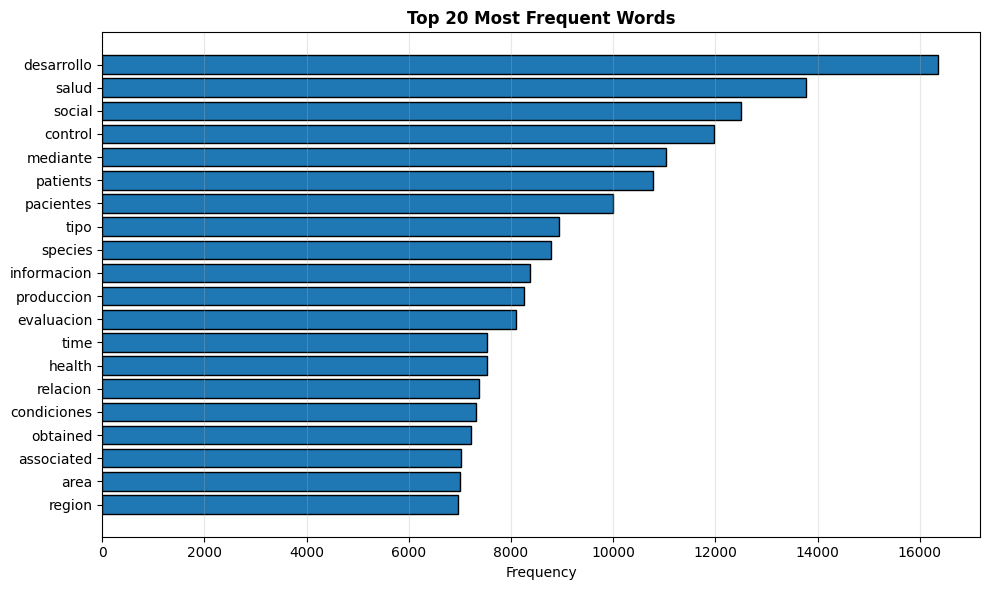

In [33]:
print("="*60)
print("MOST FREQUENT WORDS ANALYSIS")
print("="*60)

# ----------------------------------------------------------
# 1. Create cleaned text column if it doesn't exist
# ----------------------------------------------------------
if 'clean_text' not in products_bogota.columns:

    products_bogota['combined_text'] = (
        products_bogota['original_title'].fillna('').astype(str) + " " +
        products_bogota['original_description'].fillna('').astype(str)
    )

    products_bogota['clean_text'] = products_bogota['combined_text'].apply(
        lambda t: preprocess_text_full(
            t,
            lowercase=True,
            remove_accents=True,
            min_token_length=3,
            remove_numbers=True,
            remove_stopwords_flag=True
        )
    )


# ----------------------------------------------------------
# 2. Filter valid texts (minimum quality)
# ----------------------------------------------------------
valid_texts = products_bogota[
    products_bogota['clean_text'].notna() &
    (products_bogota['clean_text'].str.len() > 10)
].copy()

print(f"\nDocuments analyzed: {len(valid_texts)}")


# ----------------------------------------------------------
# 3. Apply final cleaning (additional stopwords)
# ----------------------------------------------------------
analysis_texts = valid_texts['clean_text'].apply(
    lambda t: remove_stopwords(t, stopwords=STOPWORDS_ALL | auto_df_stopwords)
)


# ----------------------------------------------------------
# 4. Extract tokens
# ----------------------------------------------------------
all_tokens = []

for txt in analysis_texts:
    if txt and len(txt) > 0:
        all_tokens.extend(txt.split())

print(f"\nTotal tokens processed: {len(all_tokens):,}")
print(f"Unique tokens: {len(set(all_tokens)):,}")


# ----------------------------------------------------------
# 5. Word frequency
# ----------------------------------------------------------
token_counter = Counter(all_tokens)

top_30 = token_counter.most_common(30)

print("\nTOP 30 MOST FREQUENT WORDS")

top_30_df = pd.DataFrame(top_30, columns=['Word', 'Frequency'])
top_30_df['%'] = (top_30_df['Frequency'] / len(all_tokens) * 100).round(3)

display(top_30_df)


# ----------------------------------------------------------
# 6. Visualization: Top words
# ----------------------------------------------------------
top_20_df = top_30_df.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top_20_df['Word'][::-1],
    top_20_df['Frequency'][::-1],
    edgecolor='black'
)

plt.xlabel("Frequency")
plt.title("Top 20 Most Frequent Words", fontweight="bold")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 2.12.2. Text Quality Analysis

TEXT QUALITY ANALYSIS

📊 QUALITY METRICS

TITLES
No useful content (0 tokens): 91 (0.1%)
Very short (1-2 tokens): 6789 (6.2%)

DESCRIPTIONS
No useful content (0 tokens): 40816 (37.2%)
Very short (1-9 tokens): 6684 (6.1%)

Records with complete good-quality text
60801 / 109836 (55.4%)


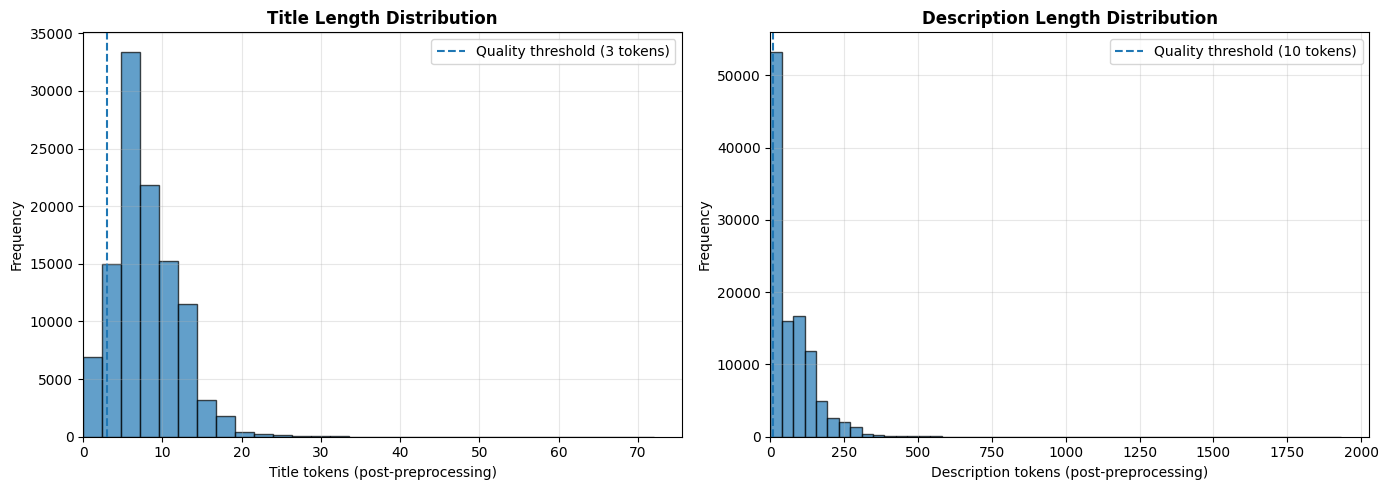


⚠️ EXAMPLES WITH VERY SHORT OR EMPTY DESCRIPTIONS


,original_title,original_description
10,Characterization of manual filters for irrigat...,NaN
28,Calling for synergized strategies to monitor a...,NaN
40,Editorial for special issue on ADRC: new ADRC ...,NaN
60,Development of Structural Type Mortars Reinfor...,NaN
71,Energy efficient alternatives to decarbonize t...,NaN
72,Drought Risk Analysis for Panela Sugarcane Pro...,NaN
73,Water Thermal Regime of River-Floodplain Syste...,NaN
76,Evaluation of the hydrological response of the...,NaN
81,EFECTO DE LA VARIABILIDAD CLIMÁTICA EN PRODUCC...,No Reportado
86,Artificial intelligence in engineering educati...,NaN


In [34]:
if 'products_bogota' not in globals():
    try:
        products_bogota = df.copy()
        print("⚠️ 'products_bogota' did not exist. Created from 'df'.")
    except:
        raise ValueError("DataFrame 'products_bogota' or 'df' not found. Load your data first.")

# ----------------------------------------------------------
# Verify required columns
# ----------------------------------------------------------
required_columns = ['original_title', 'original_description']
for col in required_columns:
    if col not in products_bogota.columns:
        raise ValueError(f"The column '{col}' does not exist in the dataframe.")

print("TEXT QUALITY ANALYSIS")
print("="*60)

# ----------------------------------------------------------
# 1. Compute title tokens
# ----------------------------------------------------------
products_bogota['title_tokens'] = (
    products_bogota['original_title']
    .fillna('')
    .astype(str)
    .apply(lambda x: len(preprocess_text_full(x).split()) if x.strip() else 0)
)

# ----------------------------------------------------------
# 2. Compute description tokens
# ----------------------------------------------------------
products_bogota['desc_tokens'] = (
    products_bogota['original_description']
    .fillna('')
    .astype(str)
    .apply(lambda x: len(preprocess_text_full(x).split()) if x.strip() else 0)
)

# ----------------------------------------------------------
# 3. Quality metrics
# ----------------------------------------------------------
total_records = len(products_bogota)

title_empty = (products_bogota['title_tokens'] == 0).sum()
title_very_short = (
    (products_bogota['title_tokens'] > 0) &
    (products_bogota['title_tokens'] < 3)
).sum()

desc_empty = (products_bogota['desc_tokens'] == 0).sum()
desc_very_short = (
    (products_bogota['desc_tokens'] > 0) &
    (products_bogota['desc_tokens'] < 10)
).sum()

print(f"\n📊 QUALITY METRICS")

print(f"\nTITLES")
print(f"No useful content (0 tokens): {title_empty} ({title_empty/total_records*100:.1f}%)")
print(f"Very short (1-2 tokens): {title_very_short} ({title_very_short/total_records*100:.1f}%)")

print(f"\nDESCRIPTIONS")
print(f"No useful content (0 tokens): {desc_empty} ({desc_empty/total_records*100:.1f}%)")
print(f"Very short (1-9 tokens): {desc_very_short} ({desc_very_short/total_records*100:.1f}%)")

# ----------------------------------------------------------
# 4. Records with good quality text
# ----------------------------------------------------------
good_quality = (
    (products_bogota['title_tokens'] >= 3) &
    (products_bogota['desc_tokens'] >= 10)
).sum()

print(f"\nRecords with complete good-quality text")
print(f"{good_quality} / {total_records} ({good_quality/total_records*100:.1f}%)")

# ----------------------------------------------------------
# 5. Visualizations
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Title length distribution
axes[0].hist(
    products_bogota['title_tokens'],
    bins=30,
    edgecolor='black',
    alpha=0.7
)

axes[0].axvline(x=3, linestyle='--', label='Quality threshold (3 tokens)')
axes[0].set_xlabel('Title tokens (post-preprocessing)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Title Length Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(left=0)

# Description length distribution
axes[1].hist(
    products_bogota['desc_tokens'],
    bins=50,
    edgecolor='black',
    alpha=0.7
)

axes[1].axvline(x=10, linestyle='--', label='Quality threshold (10 tokens)')
axes[1].set_xlabel('Description tokens (post-preprocessing)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Description Length Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(left=0)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6. Problematic examples
# ----------------------------------------------------------
print("\n⚠️ EXAMPLES WITH VERY SHORT OR EMPTY DESCRIPTIONS")

problematic_cases = products_bogota[
    products_bogota['desc_tokens'] < 10
][['original_title', 'original_description']].head(10)

display(problematic_cases)

# ----------------------------------------------------------
# 7. Clean temporary columns
# ----------------------------------------------------------
products_bogota.drop(columns=['title_tokens', 'desc_tokens'], inplace=True)

## 2.13. Cross Analysis: Language × Text × Active Coauthors

CROSS ANALYSIS: LANGUAGE × TEXT × ACTIVE COAUTHORS

📊 SUMMARY BY LANGUAGE:


,title_mean,title_median,desc_mean,desc_median,actives_mean,actives_median,actives_max,n_publications
language,,,,,,,,
Español,7.80,7.0,67.95,26.0,1.21,1.0,48,60001
Inglés,8.70,8.0,78.71,79.0,1.27,1.0,9,37254
Portugués,4.23,3.0,15.86,1.0,1.10,1.0,8,1119
Galicia,4.08,3.0,0.62,0.0,1.14,1.0,7,1110
Indonesio,5.51,5.0,1.81,0.0,1.18,1.0,4,632


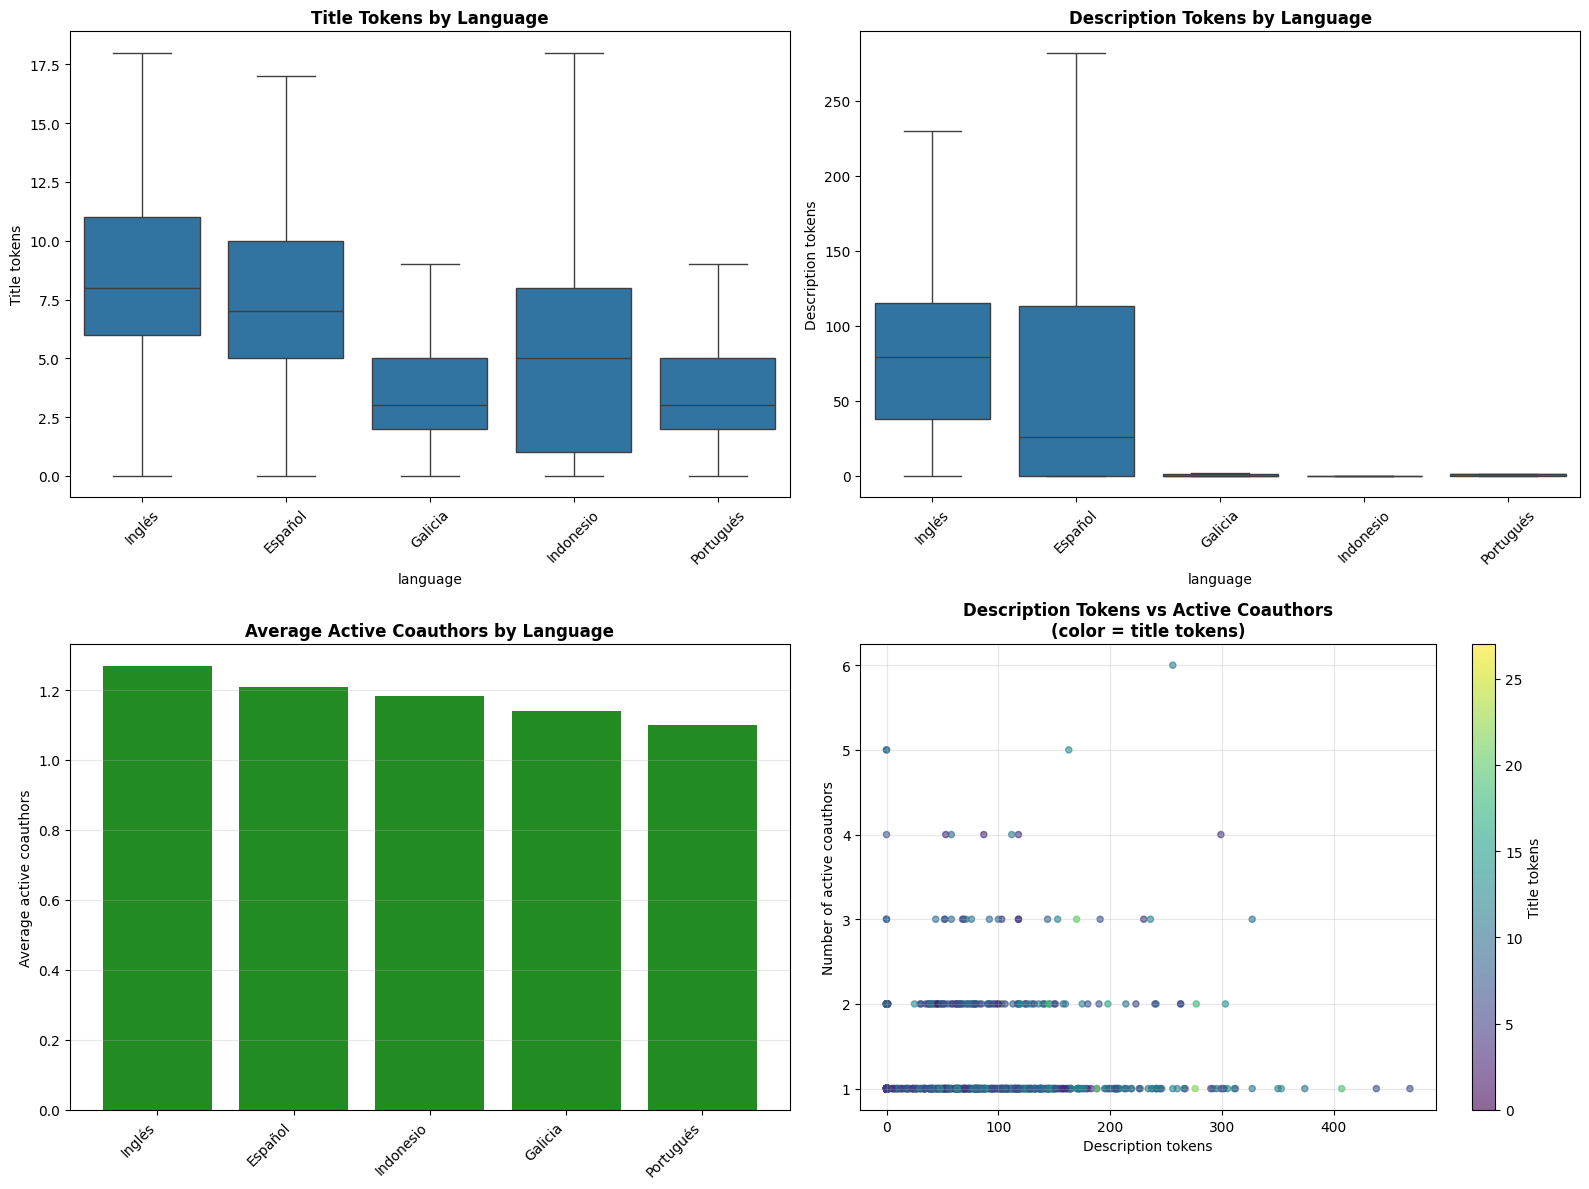


🔍 KEY FINDINGS:
1. Language with longest descriptions (avg): Inglés (78.7 tokens)
2. Language with most active coauthors per publication: Inglés (1.27)


In [35]:
print("="*60)
print("CROSS ANALYSIS: LANGUAGE × TEXT × ACTIVE COAUTHORS")
print("="*60)

# Create working copy
cross_df = products_bogota.copy()

# Text length (tokens after preprocessing)
cross_df['title_tokens_clean'] = cross_df['original_title'].fillna('').astype(str).apply(
    lambda x: len(preprocess_text_full(x).split()) if x.strip() else 0
)
cross_df['desc_tokens_clean'] = cross_df['original_description'].fillna('').astype(str).apply(
    lambda x: len(preprocess_text_full(x).split()) if x.strip() else 0
)

# Number of active coauthors per publication
def count_actives_in_paper(coauthors_str, professors_set):
    names = extract_coauthors(coauthors_str)
    return sum(1 for n in names if normalize_for_match(n) in professors_set)

cross_df['num_actives'] = cross_df['coauthors'].apply(
    lambda x: count_actives_in_paper(x, active_professors_names)
)

# Keep top languages
top_languages = cross_df['language'].value_counts().head(5).index
cross_top = cross_df[cross_df['language'].isin(top_languages)].copy()

print("\n📊 SUMMARY BY LANGUAGE:")
language_summary = cross_top.groupby('language').agg({
    'title_tokens_clean': ['mean', 'median'],
    'desc_tokens_clean': ['mean', 'median'],
    'num_actives': ['mean', 'median', 'max'],
    'language': 'count'
}).round(2)

language_summary.columns = ['title_mean', 'title_median', 'desc_mean', 'desc_median',
                            'actives_mean', 'actives_median', 'actives_max', 'n_publications']
language_summary = language_summary.sort_values('n_publications', ascending=False)
display(language_summary)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Title length by language
sns.boxplot(data=cross_top, x='language', y='title_tokens_clean', ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title('Title Tokens by Language', fontweight='bold')
axes[0, 0].set_xlabel('language')
axes[0, 0].set_ylabel('Title tokens')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Description length by language
sns.boxplot(data=cross_top, x='language', y='desc_tokens_clean', ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title('Description Tokens by Language', fontweight='bold')
axes[0, 1].set_xlabel('language')
axes[0, 1].set_ylabel('Description tokens')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Average active coauthors per language
actives_by_language = cross_top.groupby('language')['num_actives'].mean().sort_values(ascending=False)
axes[1, 0].bar(range(len(actives_by_language)), actives_by_language.values, color='forestgreen')
axes[1, 0].set_xticks(range(len(actives_by_language)))
axes[1, 0].set_xticklabels(actives_by_language.index, rotation=45, ha='right')
axes[1, 0].set_title('Average Active Coauthors by Language', fontweight='bold')
axes[1, 0].set_ylabel('Average active coauthors')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Scatter: description length vs active coauthors (color = title tokens)
sample_cross = cross_top.sample(min(1000, len(cross_top)), random_state=42)
scatter = axes[1, 1].scatter(sample_cross['desc_tokens_clean'], sample_cross['num_actives'],
                             c=sample_cross['title_tokens_clean'], cmap='viridis', alpha=0.6, s=20)
axes[1, 1].set_title('Description Tokens vs Active Coauthors\n(color = title tokens)', fontweight='bold')
axes[1, 1].set_xlabel('Description tokens')
axes[1, 1].set_ylabel('Number of active coauthors')
axes[1, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='Title tokens')

plt.tight_layout()
plt.show()

# Key findings
print("\n🔍 KEY FINDINGS:")
lang_longest_desc = language_summary['desc_mean'].idxmax()
print(f"1. Language with longest descriptions (avg): {lang_longest_desc} ({language_summary.loc[lang_longest_desc, 'desc_mean']:.1f} tokens)")

lang_most_collab = language_summary['actives_mean'].idxmax()
print(f"2. Language with most active coauthors per publication: {lang_most_collab} ({language_summary.loc[lang_most_collab, 'actives_mean']:.2f})")

# Clean temporary objects
del cross_df, cross_top

## 2.14. Secondary Analysis linked to core variables (Faculty × Missing Text)

ANALYSIS: FACULTY × MISSING DESCRIPTION

📊 Percentage of missing or not-useful descriptions by faculty:


,faculty,total_publications,desc_missing_or_short,pct_missing
0,Artes,7640,5090,66.62
5,Derecho,4268,2327,54.52
10,Veterinaria,3256,1705,52.36
4,Ciencias Humanas,10415,5448,52.31
8,Medicina,21115,9758,46.21
9,Odontología,2733,1258,46.03
3,Ciencias Económicas,3758,1602,42.63
2,Ciencias Agrarias,4884,1863,38.14
1,Ciencias,33701,12465,36.99
6,Enfermería,2838,983,34.64



🎨 Hypothesis for faculty 'Artes':
   % missing in Artes: 66.62%
   Overall average %: 45.75%
   ✅ Artes is ABOVE the average (+20.87 pp)


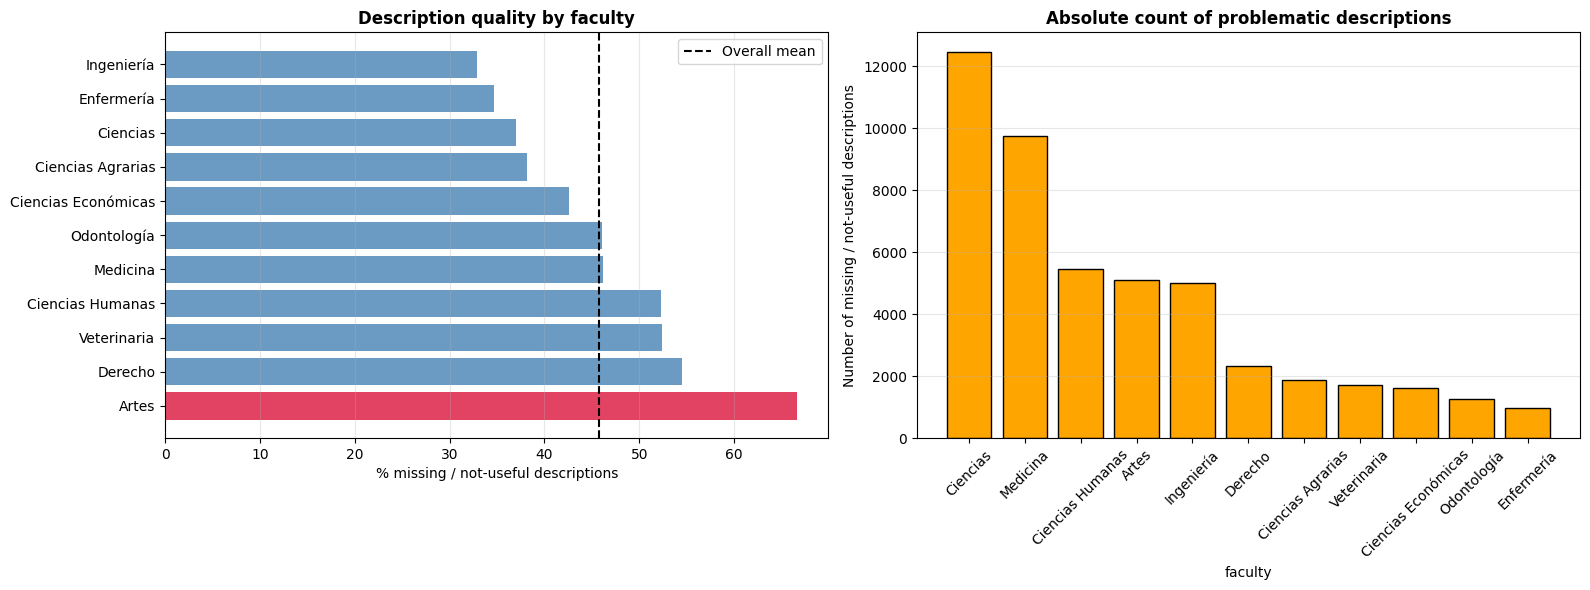


🌐 Faculty × language (only records with useful descriptions):


language,Alemán,Catalán,Español,Estonia,Francés,Galicia,Holandés,Indonesio,Inglés,Italiano,Latin,Lituano,Portugués,Rumania,Turco
faculty,,,,,,,,,,,,,,,
Artes,0.0,0.0,87.8,0.0,0.3,0.0,0.0,0.0,11.7,0.1,0.0,0.0,0.0,0.0,0.0
Ciencias,0.0,0.0,40.9,0.0,0.0,0.0,0.0,0.0,58.9,0.0,0.0,0.0,0.1,0.0,0.0
Ciencias Agrarias,0.0,0.0,51.3,0.0,0.0,0.0,0.0,0.1,48.3,0.0,0.0,0.0,0.2,0.0,0.0
Ciencias Económicas,0.0,0.0,52.2,0.0,0.3,0.0,0.0,0.0,47.3,0.0,0.0,0.0,0.2,0.0,0.0
Ciencias Humanas,0.1,0.0,73.2,0.0,0.5,0.1,0.0,0.0,25.7,0.1,0.0,0.0,0.3,0.0,0.0
Derecho,0.2,0.1,90.5,0.0,0.3,0.1,0.0,0.0,8.7,0.0,0.0,0.0,0.4,0.0,0.0
Enfermería,0.0,0.0,69.1,0.0,0.0,0.0,0.0,0.0,30.4,0.0,0.0,0.0,0.5,0.0,0.0
Ingeniería,0.1,0.0,45.7,0.0,0.1,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.1,0.0,0.0
Medicina,0.0,0.0,47.9,0.0,0.0,0.0,0.0,0.1,51.7,0.0,0.0,0.0,0.1,0.0,0.0


In [36]:
print("="*60)
print("ANALYSIS: FACULTY × MISSING DESCRIPTION")
print("="*60)

# Define what counts as a missing / not useful description
def missing_description(desc):
    if pd.isna(desc):
        return True
    desc_str = str(desc).strip()
    if desc_str == '' or is_null_by_convention(desc_str):
        return True
    # Consider very short descriptions as not useful
    desc_clean = preprocess_text_full(desc_str)
    return len(desc_clean.split()) < 10

products_bogota['desc_missing_or_short'] = products_bogota['original_description'].apply(missing_description)

# Summary by faculty
faculty_desc_summary = products_bogota.groupby('faculty').agg(
    total_publications=('faculty', 'count'),
    desc_missing_or_short=('desc_missing_or_short', 'sum')
).reset_index()

faculty_desc_summary['pct_missing'] = (
    faculty_desc_summary['desc_missing_or_short'] / faculty_desc_summary['total_publications'] * 100
).round(2)

faculty_desc_summary = faculty_desc_summary.sort_values('pct_missing', ascending=False)

print("\n📊 Percentage of missing or not-useful descriptions by faculty:")
display(faculty_desc_summary)

# Hypothesis test for faculty 'Artes'
if 'Artes' in faculty_desc_summary['faculty'].values:
    artes_pct = faculty_desc_summary[faculty_desc_summary['faculty'] == 'Artes']['pct_missing'].iloc[0]
    overall_mean = faculty_desc_summary['pct_missing'].mean()
    
    print(f"\n🎨 Hypothesis for faculty 'Artes':")
    print(f"   % missing in Artes: {artes_pct:.2f}%")
    print(f"   Overall average %: {overall_mean:.2f}%")
    
    if artes_pct > overall_mean:
        print(f"   ✅ Artes is ABOVE the average (+{artes_pct - overall_mean:.2f} pp)")
    else:
        print(f"   ℹ️ Artes is BELOW the average ({artes_pct - overall_mean:.2f} pp)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: % missing by faculty
colors = ['crimson' if f == 'Artes' else 'steelblue' for f in faculty_desc_summary['faculty']]
axes[0].barh(faculty_desc_summary['faculty'], faculty_desc_summary['pct_missing'], color=colors, alpha=0.8)
axes[0].axvline(x=faculty_desc_summary['pct_missing'].mean(), color='black', linestyle='--', label='Overall mean')
axes[0].set_xlabel('% missing / not-useful descriptions')
axes[0].set_title('Description quality by faculty', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Absolute counts
df_plot = faculty_desc_summary.sort_values('desc_missing_or_short', ascending=False)
axes[1].bar(df_plot['faculty'], df_plot['desc_missing_or_short'], color='orange', edgecolor='black')
axes[1].set_xlabel('faculty')
axes[1].set_ylabel('Number of missing / not-useful descriptions')
axes[1].set_title('Absolute count of problematic descriptions', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Relation with language
print("\n🌐 Faculty × language (only records with useful descriptions):")
usable_products = products_bogota[~products_bogota['desc_missing_or_short']]
faculty_language_usable = pd.crosstab(
    usable_products['faculty'],
    usable_products['language'],
    normalize='index'
).round(3) * 100

display(faculty_language_usable)

# Clean temporary column
products_bogota.drop(columns=['desc_missing_or_short'], inplace=True)

## 2.15. Executive Summary (Text, Active Coauthors, Language Focus)

In [37]:
# Final EDA summary (text, active coauthors, language focus)
print("EXECUTIVE SUMMARY OF EDA - MAIN FOCUS")

# Base text metrics
valid_titles = products_bogota['original_title'].notna().sum()
valid_descriptions = products_bogota['original_description'].notna().sum()

title_tokens = products_bogota['original_title'].fillna('').astype(str).apply(
    lambda x: len(preprocess_text_full(x).split()) if x.strip() else 0
)
desc_tokens = products_bogota['original_description'].fillna('').astype(str).apply(
    lambda x: len(preprocess_text_full(x).split()) if x.strip() else 0
)

# Active coauthors metrics
papers_with_actives = products_bogota['coauthors'].apply(
    lambda x: has_active_professor(x, active_professors_names)
).sum()

# Main language distribution
language_dist = products_bogota['language'].value_counts(dropna=False)
top_5_languages = language_dist.head(5)

summary_text = f"""
DATASET:
  - {len(products_bogota)} academic production records

FOCUS 1: TEXT VARIABLES
  - Records with non-null title: {valid_titles} ({valid_titles/len(products_bogota)*100:.1f}%)
  - Records with non-null description: {valid_descriptions} ({valid_descriptions/len(products_bogota)*100:.1f}%)
  - Avg title length (post-preprocessing): {title_tokens.mean():.2f} tokens
  - Avg description length (post-preprocessing): {desc_tokens.mean():.2f} tokens
  - Very short titles (<3 tokens): {(title_tokens < 3).sum()} ({(title_tokens < 3).sum()/len(products_bogota)*100:.1f}%)
  - Not-useful descriptions (<10 tokens): {(desc_tokens < 10).sum()} ({(desc_tokens < 10).sum()/len(products_bogota)*100:.1f}%)

FOCUS 2: ACTIVE COAUTHORS
  - Records with at least 1 active faculty: {papers_with_actives} ({papers_with_actives/len(products_bogota)*100:.1f}%)
  - Avg coauthors per production (overall): {products_bogota['num_coauthors'].mean():.2f}
  - Note: non-faculty collaborators were filtered for main-frequency analysis

FOCUS 3: LANGUAGE
  - Detected languages (including NaN): {products_bogota['language'].nunique(dropna=False)}
  - Records without language specified: {products_bogota['language'].isna().sum()} ({products_bogota['language'].isna().sum()/len(products_bogota)*100:.1f}%)
  - Top 5 languages by frequency:
{top_5_languages.to_string()}

RELATED ANALYSES (SECONDARY, CONNECTED TO FOCUS)
  - faculty × missing / not-useful description: assessed to identify capture biases
  - language × text length × active coauthors: evaluated in cross-analysis

OPERATIONAL CONCLUSION FOR NEXT PHASE (PREPROCESSING NOTEBOOK)
  1. Prioritize records with useful descriptions for topic modeling.
  2. Keep titles as fallback when descriptions are missing.
  3. Use active-faculty filter for primary authorship metrics.
  4. Handle records without language explicitly (heuristic or auto-detection).
"""

print(summary_text)

EXECUTIVE SUMMARY OF EDA - MAIN FOCUS



DATASET:
  - 109836 academic production records

FOCUS 1: TEXT VARIABLES
  - Records with non-null title: 109835 (100.0%)
  - Records with non-null description: 69928 (63.7%)
  - Avg title length (post-preprocessing): 7.86 tokens
  - Avg description length (post-preprocessing): 64.24 tokens
  - Very short titles (<3 tokens): 6880 (6.3%)
  - Not-useful descriptions (<10 tokens): 47500 (43.2%)

FOCUS 2: ACTIVE COAUTHORS
  - Records with at least 1 active faculty: 109836 (100.0%)
  - Avg coauthors per production (overall): 26.98
  - Note: non-faculty collaborators were filtered for main-frequency analysis

FOCUS 3: LANGUAGE
  - Detected languages (including NaN): 31
  - Records without language specified: 7733 (7.0%)
  - Top 5 languages by frequency:
language
Español      60001
Inglés       37254
NaN           7733
Portugués     1119
Galicia       1110

RELATED ANALYSES (SECONDARY, CONNECTED TO FOCUS)
  - faculty × missing / not-useful description: assessed to identify capture biases
  -